<a id="4"></a>
<h1 style="background-color:#16DCC9;font-family:monospace;font-size:250%;text-align:center">Project Understanding</h1>

**Define the Problem:**



**Purpose:**





<h1 style="background-color:#16DCC9;font-family:Calibri;font-size:200%;text-align:center">Proposed Solution</h1>

**Modeling Design:**


**Objective:**


**Step 1: Identify the problem and the Target.**

**Step 2:  Exploratory Data Analysis**

K-means Clustering**


**Step 3: Modeling**


In [232]:
import plotly.graph_objects as go
from plotly.offline import init_notebook_mode,iplot
init_notebook_mode(connected=True)

fig = go.Figure(go.Sankey(
    node=dict(
        pad=25,
        thickness=25,
        line=dict(color="black", width=0.5),
        label=["Problem Understanding", "Data Understanding", "Data Cleaning", "EDA", "Feature Selection", "Modeling", "Hyperparameter Tuning", "Interpretation", "Deployment", "Insights"],
        color="blue"
    ),
    link=dict(
        source=[0, 1, 2, 3, 4, 5, 6, 7, 8], # indices correspond to labels in the node list
        target=[1, 2, 3, 4, 5, 6, 7, 8, 9],
        value=[1, 1, 1, 1, 1, 1, 1, 1, 1]
    )
))

fig.update_layout(title_text="Analysis Workflow", font_size=13)
fig.show()


<a id="4"></a>
<h1 style="background-color:#16DCC9;font-family:Calibri;font-size:200%;text-align:center">Data Quality</h1>

<a id='Load_Libraries'></a>
<h2 style="color:blue">Load Libraries</h2>

In [233]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as mno
%matplotlib inline
plt.style.use('ggplot')

# to visualize all the columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [234]:
# load the data
file_path = './Data/filtered_crime_with_census.csv'
df = pd.read_csv(file_path)


<a id='Read_Dataset'></a>
<h2 style="color:blue">Data At a Glance</h2>

In [235]:
df.head()

,ZCTA_YEAR_KEY,CRIME_TOTAL,POP_AGE_0_4,POP_AGE_5_9,POP_AGE_10_14,POP_AGE_15_17,POP_AGE_18_19,POP_AGE_20_24,POP_AGE_25_29,POP_AGE_30_34,POP_AGE_35_44,POP_AGE_45_54,POP_AGE_55_64,POP_AGE_65_74,POP_AGE_75_84,POP_AGE_85_100,POP_WHITE,POP_BLACK,POP_AIAN,POP_ASIAN,POP_HNPI,POP_HISPANIC,POP_MALE,POP_FEMALE,POP_TOTAL,POP_DENSITY,POV_WHITE,POV_BLACK,POV_AIAN,POV_ASIAN,POV_HNPI,POV_HISPANIC,POV_TOTAL,POV_RATE,AREA_SQMIL,YEAR,CRIME_RATE,COVID_LOCKDOWN
0,90044_2016,9649,9168.0,9753.0,9099.0,5326.0,3620.0,9456.0,9277.0,8160.0,14444.0,13375.0,10607.0,5436.0,2812.0,971.0,1062.0,40095.0,165.0,294.0,95.0,69793.0,53805.0,57699.0,111504.0,19711.492828,247.0,13377.0,70.0,29.0,23.0,24610.0,38356.0,34.398766,6.081368,2016.0,86.535012,0
1,90044_2017,7192,8643.0,9617.0,9080.0,5307.0,3444.0,9159.0,9346.0,8255.0,14457.0,13376.0,10880.0,5311.0,2780.0,1008.0,1057.0,39574.0,160.0,295.0,0.0,69483.0,53371.0,57292.0,110663.0,19564.489002,218.0,13248.0,68.0,36.0,25.0,23890.0,37485.0,33.873110,6.081368,2017.0,64.990105,0
2,90044_2022,7124,6881.0,8115.0,8749.0,5285.0,3403.0,8046.0,8335.0,8164.0,14579.0,12643.0,11821.0,7243.0,2928.0,1015.0,1063.0,35867.0,184.0,540.0,187.0,69366.0,51303.0,55904.0,107207.0,18851.439106,314.0,11347.0,99.0,128.0,42.0,19676.0,31606.0,29.481284,6.081048,2022.0,66.450885,0
3,90044_2018,7013,8077.0,9345.0,9038.0,5178.0,3439.0,8824.0,9208.0,8202.0,14518.0,13161.0,11160.0,5322.0,2709.0,1078.0,1072.0,39174.0,206.0,294.0,94.0,68419.0,52704.0,56555.0,109259.0,19273.338404,237.0,12572.0,74.0,28.0,9.0,20781.0,33701.0,30.845056,6.081368,2018.0,64.186932,0
4,91342_2016,6894,6434.0,7098.0,7190.0,4793.0,3086.0,7712.0,7730.0,6933.0,13269.0,12530.0,10549.0,5949.0,2743.0,1154.0,12207.0,4313.0,257.0,5088.0,44.0,75261.0,48534.0,48636.0,97170.0,8884.914318,1361.0,604.0,35.0,492.0,2.0,11828.0,14322.0,14.739117,136.392556,2016.0,70.947823,0


In [236]:
#check if there is null value in Target column.
df['CRIME_RATE'].isnull().sum()

0

In [237]:
# shape of the dataset
df.shape

(1756, 38)

In [238]:
# Info of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1756 entries, 0 to 1755
Data columns (total 38 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ZCTA_YEAR_KEY   1756 non-null   object 
 1   CRIME_TOTAL     1756 non-null   int64  
 2   POP_AGE_0_4     1756 non-null   float64
 3   POP_AGE_5_9     1756 non-null   float64
 4   POP_AGE_10_14   1756 non-null   float64
 5   POP_AGE_15_17   1756 non-null   float64
 6   POP_AGE_18_19   1756 non-null   float64
 7   POP_AGE_20_24   1756 non-null   float64
 8   POP_AGE_25_29   1756 non-null   float64
 9   POP_AGE_30_34   1756 non-null   float64
 10  POP_AGE_35_44   1756 non-null   float64
 11  POP_AGE_45_54   1756 non-null   float64
 12  POP_AGE_55_64   1756 non-null   float64
 13  POP_AGE_65_74   1756 non-null   float64
 14  POP_AGE_75_84   1756 non-null   float64
 15  POP_AGE_85_100  1756 non-null   float64
 16  POP_WHITE       1756 non-null   float64
 17  POP_BLACK       1756 non-null   f

In [239]:
df.describe()

,CRIME_TOTAL,POP_AGE_0_4,POP_AGE_5_9,POP_AGE_10_14,POP_AGE_15_17,POP_AGE_18_19,POP_AGE_20_24,POP_AGE_25_29,POP_AGE_30_34,POP_AGE_35_44,POP_AGE_45_54,POP_AGE_55_64,POP_AGE_65_74,POP_AGE_75_84,POP_AGE_85_100,POP_WHITE,POP_BLACK,POP_AIAN,POP_ASIAN,POP_HNPI,POP_HISPANIC,POP_MALE,POP_FEMALE,POP_TOTAL,POP_DENSITY,POV_WHITE,POV_BLACK,POV_AIAN,POV_ASIAN,POV_HNPI,POV_HISPANIC,POV_TOTAL,POV_RATE,AREA_SQMIL,YEAR,CRIME_RATE,COVID_LOCKDOWN
count,1756.000000,1756.000000,1756.000000,1756.000000,1756.000000,1756.000000,1756.000000,1756.000000,1756.000000,1756.000000,1756.000000,1756.000000,1756.000000,1756.000000,1756.000000,1756.000000,1756.000000,1756.000000,1756.000000,1756.000000,1756.000000,1756.000000,1756.000000,1756.000000,1756.000000,1756.000000,1756.000000,1756.000000,1756.000000,1756.000000,1756.000000,1756.000000,1756.000000,1756.000000,1756.000000,1756.000000,1756.000000
mean,1355.182232,1925.963554,2063.932802,2069.865604,1267.975513,961.740319,2479.908314,2717.301822,2844.101367,5119.772210,4670.023918,4019.775626,2599.226082,1346.378132,617.759112,10154.420843,3412.219248,62.906036,4490.538724,62.384966,16516.374146,17145.334852,17558.389522,34703.724374,13922.009074,1067.197608,753.591116,12.731207,587.976082,8.592825,3615.899203,6045.988041,15.737319,8.238805,2017.927107,47.626051,0.204442
std,1366.277425,1610.929765,1745.527567,1750.237127,1077.306976,931.588101,2087.377963,1934.060328,1937.398205,3317.338452,2849.081062,2354.755699,1468.216353,760.742843,359.220084,8656.267361,5817.104949,48.014098,5208.232351,168.628950,18586.966545,10904.545153,11135.632976,22000.329399,8933.471704,1035.188004,1567.355675,16.049090,872.263046,28.956297,5226.847019,6378.798515,9.555239,37.217167,3.244515,59.981306,0.403408
min,1.000000,0.000000,0.000000,0.000000,0.000000,5.000000,19.000000,39.000000,41.000000,19.000000,21.000000,12.000000,0.000000,0.000000,0.000000,11.000000,9.000000,0.000000,0.000000,0.000000,92.000000,729.000000,114.000000,1331.000000,247.825363,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.066423,2013.000000,0.009295,0.000000
25%,122.000000,836.000000,850.750000,855.500000,515.000000,372.750000,999.500000,1264.750000,1397.750000,2801.000000,2863.500000,2486.750000,1638.750000,836.750000,364.000000,1882.000000,582.250000,29.000000,881.500000,10.000000,2909.750000,9809.250000,10520.750000,20483.500000,7973.102663,272.750000,52.750000,1.000000,78.000000,0.000000,308.750000,1574.000000,8.169462,1.840766,2015.000000,9.087411,0.000000
50%,1073.500000,1524.000000,1645.000000,1640.000000,1011.500000,748.500000,2005.500000,2374.000000,2600.500000,4693.000000,4367.000000,3899.500000,2609.000000,1348.500000,608.500000,9047.000000,1290.500000,57.000000,2436.500000,27.000000,8452.000000,15548.500000,16252.500000,31751.500000,12397.093839,824.500000,178.000000,7.000000,228.500000,2.000000,1173.500000,3760.500000,13.800461,3.401355,2018.000000,40.380383,0.000000
75%,2222.500000,2603.500000,2812.500000,2872.000000,1779.000000,1319.250000,3469.500000,3873.250000,3886.250000,6839.500000,6389.500000,5354.500000,3436.500000,1814.750000,836.000000,16888.750000,2709.250000,85.000000,6561.500000,50.000000,24521.750000,23270.500000,23894.750000,47479.000000,17642.731896,1520.500000,568.250000,19.000000,727.750000,6.000000,5208.750000,9011.750000,21.407238,5.507736,2021.000000,56.109960,0.000000
max,9649.000000,11249.000000,11348.000000,10292.000000,6143.000000,8564.000000,12770.000000,10078.000000,10052.000000,17401.000000,14344.000000,12154.000000,7685.000000,4626.000000,2004.000000,39087.000000,40095.000000,347.000000,37498.000000,2422.000000,106525.000000,60568.000000,58593.000000,119161.000000,60568.336706,7603.000000,14934.000000,113.000000,5956.000000,656.000000,46805.000000,52393.000000,58.488438,599.378584,2023.000000,683.965015,1.000000


<a id='Data_Quality'></a>
<h2 style="color:blue">Feature Description</h2>

In [240]:
# List names of all columns
df.columns

Index(['ZCTA_YEAR_KEY', 'CRIME_TOTAL', 'POP_AGE_0_4', 'POP_AGE_5_9',
       'POP_AGE_10_14', 'POP_AGE_15_17', 'POP_AGE_18_19', 'POP_AGE_20_24',
       'POP_AGE_25_29', 'POP_AGE_30_34', 'POP_AGE_35_44', 'POP_AGE_45_54',
       'POP_AGE_55_64', 'POP_AGE_65_74', 'POP_AGE_75_84', 'POP_AGE_85_100',
       'POP_WHITE', 'POP_BLACK', 'POP_AIAN', 'POP_ASIAN', 'POP_HNPI',
       'POP_HISPANIC', 'POP_MALE', 'POP_FEMALE', 'POP_TOTAL', 'POP_DENSITY',
       'POV_WHITE', 'POV_BLACK', 'POV_AIAN', 'POV_ASIAN', 'POV_HNPI',
       'POV_HISPANIC', 'POV_TOTAL', 'POV_RATE', 'AREA_SQMIL', 'YEAR',
       'CRIME_RATE', 'COVID_LOCKDOWN'],
      dtype='object')

So we have 26 features.

### Age re - aggregate

- We convert counts to shares by dividing by POP_TOTAL.

- For regression, we apply the k−1 rule: drop share_mid (35–54) as the baseline to avoid perfect multicollinearity. Coefficients on the remaining shares read as replacement effects relative to mid.

- We also create log_density = log(POP_DENSITY + 1) to reduce skewness.

- If POV_RATE is in 0–100, scale to 0–1 before modeling.

- Use X (raw) or X_std (standardized).

- Target y uses CRIME_RATE. 

We aggregate fine-grained age counts into 5 broader bins: child (0–14), teen (15–19), young (20–34), mid (35–54), old (55+).

- We convert counts to shares by dividing by POP_TOTAL.

- For regression, we apply the k−1 rule: drop share_mid (35–54) as the baseline to avoid perfect multicollinearity. Coefficients on the remaining shares read as replacement effects relative to mid.

- We also create log_density = log(POP_DENSITY + 1) to reduce skewness.

- If POV_RATE is in 0–100, scale to 0–1 before modeling.

- Use X (raw) or X_std (standardized).

- Target y uses CRIME_RATE.

In [241]:
REQUIRED_COLS = [
    "POP_TOTAL", "POP_AGE_0_4", "POP_AGE_5_9", "POP_AGE_10_14",
    "POP_AGE_15_17", "POP_AGE_18_19", "POP_AGE_20_24", "POP_AGE_25_29",
    "POP_AGE_30_34", "POP_AGE_35_44", "POP_AGE_45_54", "POP_AGE_55_64",
    "POP_AGE_65_74", "POP_AGE_75_84", "POP_AGE_85_100"
]
missing = [c for c in REQUIRED_COLS if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Each group is a sum of original fine-grained age counts
AGE_GROUPS = {
    # 0–14
    "age_child_cnt": ["POP_AGE_0_4", "POP_AGE_5_9", "POP_AGE_10_14"],
    # 15–19
    "age_teen_cnt":  ["POP_AGE_15_17", "POP_AGE_18_19"],
    # 20–34
    "age_young_cnt": ["POP_AGE_20_24", "POP_AGE_25_29", "POP_AGE_30_34"],
    # 35–54  (this will be our baseline group later)
    "age_mid_cnt":   ["POP_AGE_35_44", "POP_AGE_45_54"],
    # 55+
    "age_old_cnt":   ["POP_AGE_55_64", "POP_AGE_65_74", "POP_AGE_75_84", "POP_AGE_85_100"],
}

for new_col, src_cols in AGE_GROUPS.items():
    df[new_col] = df[src_cols].fillna(0).sum(axis=1)

grp_sum = df[[c for c in df.columns if c.endswith("_cnt")]].sum(axis=1)
mismatch = (grp_sum - df["POP_TOTAL"]).abs()
if (mismatch > 1e-6).any():
    
    print("Warning: age-group counts do not exactly sum to POP_TOTAL on some rows. Verify inputs.")


den = df["POP_TOTAL"].replace({0: np.nan})
df["share_child"] = df["age_child_cnt"] / den
df["share_teen"]  = df["age_teen_cnt"]  / den
df["share_young"] = df["age_young_cnt"] / den
df["share_mid"]   = df["age_mid_cnt"]   / den  # baseline group
df["share_old"]   = df["age_old_cnt"]   / den

share_cols = ["share_child", "share_teen", "share_young", "share_mid", "share_old"]
df[share_cols] = df[share_cols].clip(lower=0, upper=1)

sum_share = df[share_cols].sum(axis=1)
if ((sum_share - 1).abs() > 1e-3).any():
    print("Note: age shares do not sum to 1 for some rows (tolerance=1e-3). Check raw inputs if needed.")


AGE_SHARE_FOR_MODEL = ["share_child", "share_teen", "share_young", "share_old"]  # k-1


df["log_density"] = np.log1p(df["POP_DENSITY"])


model_cols = ["POV_RATE", "log_density", "COVID_LOCKDOWN"] + AGE_SHARE_FOR_MODEL
X = df[model_cols].copy()

y = df["CRIME_RATE"].astype(float)

to_standardize = ["POV_RATE", "log_density"] + AGE_SHARE_FOR_MODEL
X_std = X.copy()
X_std[to_standardize] = (X_std[to_standardize] - X_std[to_standardize].mean()) / X_std[to_standardize].std(ddof=0)

print("Prepared features:", list(X.columns))

Prepared features: ['POV_RATE', 'log_density', 'COVID_LOCKDOWN', 'share_child', 'share_teen', 'share_young', 'share_old']


**Note: When handling age group features (which are compositional shares), we need to use $k-1$ features instead of putting all of them into the model. This is because when building a regression model, using all shares will cause perfect multicollinearity (a variation of the dummy variable trap), leading to an infinite VIF and making the model unsolvable.The correct approach (the $k-1$ strategy) is to omit one of the shares, treating it as the "baseline" group. This way, the coefficients of the remaining age share variables (e.g., $\gamma_{\text{young}}$) are interpreted as: holding other variables constant, for every one percentage point increase in that age group's share, the resulting impact on the dependent variable (e.g., crime rate) is the marginal effect relative to the omitted "baseline group."**

In [242]:
df[model_cols].head()

,POV_RATE,log_density,COVID_LOCKDOWN,share_child,share_teen,share_young,share_old
0,34.398766,9.889008,0,0.251291,0.080230,0.241184,0.177805
1,33.873110,9.881523,0,0.247056,0.079078,0.241815,0.180539
2,29.481284,9.844398,0,0.221487,0.081039,0.228950,0.214604
3,30.845056,9.866530,0,0.242177,0.078868,0.240108,0.185513
4,14.739117,9.092223,0,0.213255,0.081085,0.230267,0.209890


#### A glance at numericals' distribution.

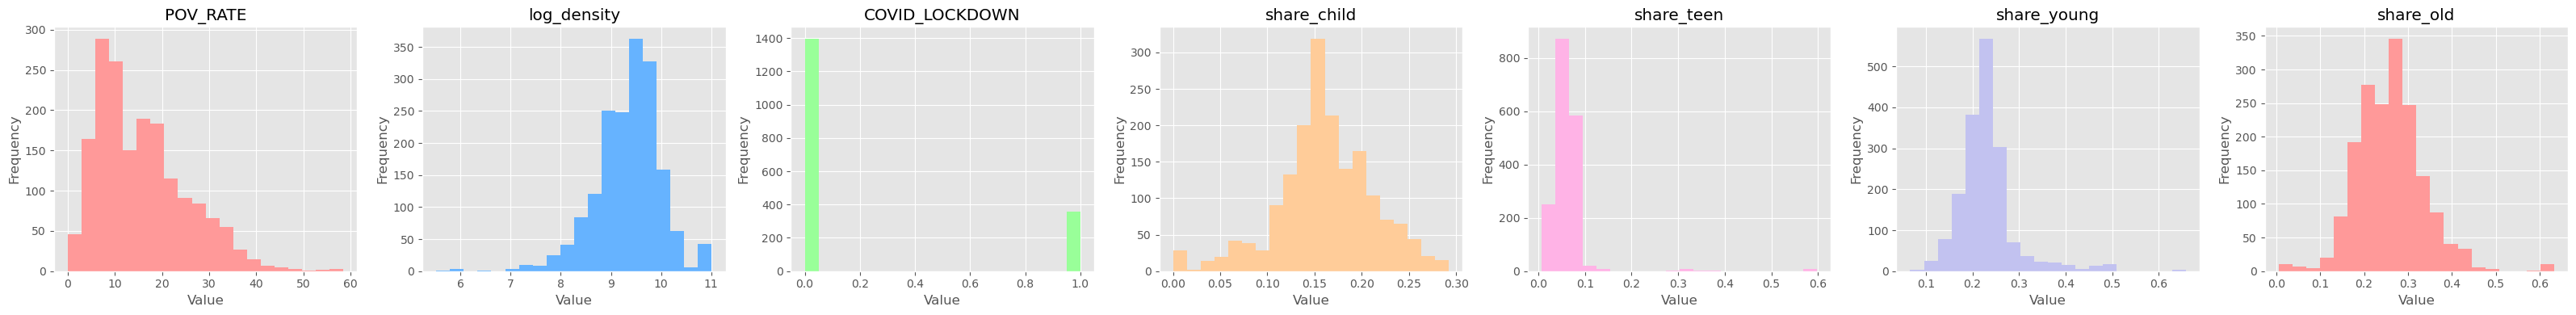

In [243]:
import matplotlib.pyplot as plt
import pandas as pd

fig, axs = plt.subplots(1, 7, figsize=(32, 4)) # Adjusted figsize for a single row

# Define a list of colors
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#ffb3e6', '#c2c2f0', '#ff9999']

for i, col in enumerate(model_cols):

    axs[i].hist(df[col].dropna(), bins=20, color=colors[i])
    axs[i].set_title(col)
    axs[i].set_xlabel('Value')
    axs[i].set_ylabel('Frequency')

plt.tight_layout()
# Save the figure to a file
fig.savefig('numeric_features_distribution.png', dpi=300)
plt.show()

<a id='Data_Quality'></a>
<h2 style="color:blue">Missing Values</h2>

<a id='Data_Quality'></a>
<h3 style="color:blue">A glance of Missing Values</h2>

In [248]:
# To check the missing values in the dataset.
pd.DataFrame({'missing':df[model_cols].isnull().sum(),
              'missing percentage': df[model_cols].isnull().sum() / len(df)*100
              }
).sort_values(by=['missing'],ascending = False)

,missing,missing percentage
POV_RATE,0,0.0
log_density,0,0.0
COVID_LOCKDOWN,0,0.0
share_child,0,0.0
share_teen,0,0.0
share_young,0,0.0
share_old,0,0.0


**Now let's look at the distribution of missing values in dataset**

<Axes: >

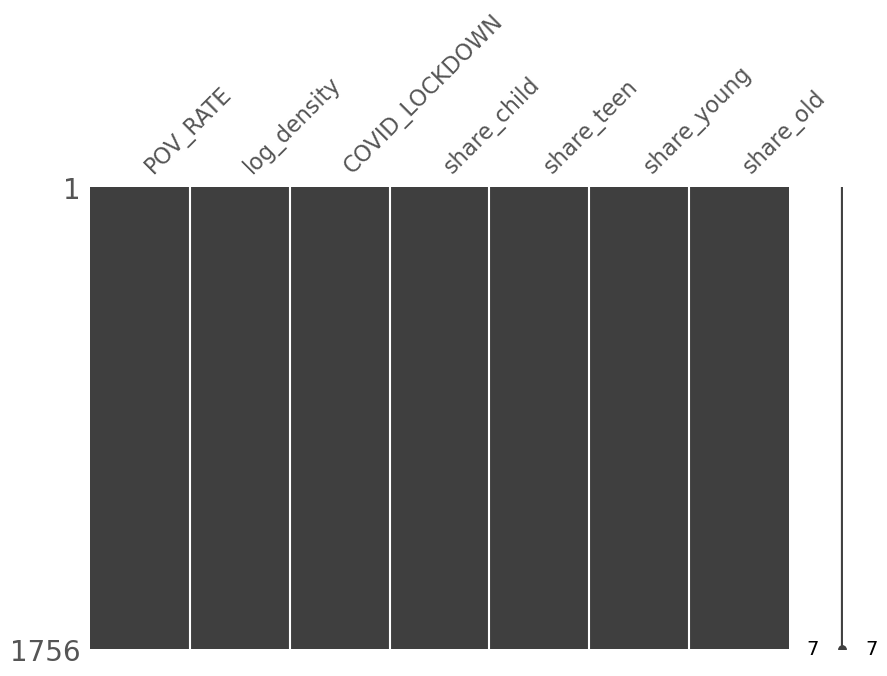

In [249]:
mno.matrix(df[model_cols],figsize=(10, 6))

## Data ETL

**This script executes a complete geospatial ETL (Extract, Transform, Load) pipeline: it starts by loading year-by-year attribute data (like crime and population) from a CSV, while simultaneously loading geographic boundaries from a zipped shapefile. Next, it standardizes and cleans both datasets by parsing ZCTA (zip code area) identifiers, and then inner-joins the attributes onto the geographic boundaries. Finally, it projects the merged data into a metric coordinate system (to enable area calculations), adds quality control flags (such as flag_small_pop), and exports a single, clean, analysis-ready GeoPackage file (GeoData_all_years.gpkg).**

In [250]:

import numpy as np
import pandas as pd
import geopandas as gpd
from pathlib import Path

pd.set_option("display.max_columns", 200)


ATTR_CSV = "./Data/filtered_crime_with_census.csv"   # attributes by ZCTA×YEAR

ZCTA_BOUNDARY = "./Data/la_zcta5_2020.zip"

COLS = {
    "zcta_from_key": "ZCTA_YEAR_KEY",  
    "year": "YEAR",
    "crime_total": "CRIME_TOTAL",
    "pop_total": "POP_TOTAL",
    "pov_rate": "POV_RATE",       
    "pop_density": "POP_DENSITY",
}

# Target projected CRS in meters (Los Angeles options: 26945=CA StatePlane Zone 5 (m), 32611=UTM 11N, 3310=CA Albers)
TARGET_EPSG = 26945

POP_MIN_FLAG = 2000        
AREA_MIN_SQKM_FLAG = 0.5     


# STEP 2 — Load attribute table and clean it

def load_and_clean_attributes(csv_path: str, colmap: dict) -> pd.DataFrame:
    """
    Load ZCTA×YEAR attributes and create a proper 5-digit ZCTA column by parsing ZCTA_YEAR_KEY.
    - Accepts either a real ZCTA column (colmap["zcta"]) or an embedded key colmap["zcta_from_key"].
    - Normalizes ZCTA to 5-digit string; casts YEAR to int.
    - Basic sanity on key numeric columns.
    """
    import re
    df_raw = pd.read_csv(csv_path)
    df_raw.columns = [c.strip() for c in df_raw.columns]

    zcta_col_direct = colmap.get("zcta") 
    zcta_from_key = colmap.get("zcta_from_key") 

    required_others = [colmap["year"], colmap["crime_total"], colmap["pop_total"], colmap["pov_rate"], colmap["pop_density"]]
    missing_other = [c for c in required_others if c not in df_raw.columns]
    if missing_other:
        raise ValueError(f"Missing required columns: {missing_other}")

    df = df_raw.copy()

    # Build ZCTA
    if zcta_col_direct and zcta_col_direct in df.columns:
        zc = df[zcta_col_direct].astype(str).str.extract(r"(\d{5})", expand=False)
        df["ZCTA"] = zc.str.zfill(5)
    elif zcta_from_key and zcta_from_key in df.columns:
        key = df[zcta_from_key].astype(str)
        zc = key.str.extract(r"^\D*?(\d{5})", expand=False) 
        zc = zc.fillna(key.str.extract(r"(\d{5})", expand=False))
        df["ZCTA"] = zc.str.zfill(5)
    else:
        raise ValueError("Neither a dedicated ZCTA column nor zcta_from_key found. "
                         "Provide COLS['zcta'] or COLS['zcta_from_key'].")

    # YEAR
    df[colmap["year"]] = pd.to_numeric(df[colmap["year"]], errors="coerce").astype("Int64")
    df.rename(columns={
        colmap["year"]: "YEAR",
        colmap["crime_total"]: "CRIME_TOTAL",
        colmap["pop_total"]: "POP_TOTAL",
        colmap["pov_rate"]: "POV_RATE",
        colmap["pop_density"]: "POP_DENSITY",
    }, inplace=True)

    # Cast numerics & basic sanity
    for c in ["CRIME_TOTAL", "POP_TOTAL", "POP_DENSITY", "POV_RATE"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
            df.loc[df[c] < 0, c] = np.nan

    # Drop rows with missing essentials
    df = df.dropna(subset=["ZCTA", "YEAR", "POP_TOTAL"]).copy()
    df["YEAR"] = df["YEAR"].astype(int)

    # Quick QC prints
    key_cols = ["CRIME_TOTAL","POP_TOTAL","POV_RATE","POP_DENSITY"]
    print("Null counts (key columns):")
    print(df[key_cols].isna().sum().to_string())
    print("ZCTA sample:", df["ZCTA"].head().tolist())
    return df


def load_boundaries(boundary_path: str) -> gpd.GeoDataFrame:
    """
    Load County-level ZCTA polygons (zip/shapefile/geojson), standardize ZCTA to 5-digit string,
    dissolve multi-polygons, and fix invalid geometries.
    """
    from pathlib import Path
    from zipfile import ZipFile
    import fiona

    p = Path(boundary_path)

    if p.suffix.lower() == ".zip":
        with ZipFile(p) as zf:
            shp_names = [n for n in zf.namelist() if n.lower().endswith(".shp")]
            if not shp_names:
                raise FileNotFoundError(f"No .shp found inside zip: {p}")
            uri = f"zip://{p.resolve()}!{shp_names[0]}"
        gdf = gpd.read_file(uri)
    elif p.suffix.lower() == ".shp" and not p.with_suffix(".shx").exists():
        zip_path = p.with_suffix(".zip")
        if zip_path.exists():
            with ZipFile(zip_path) as zf:
                shp_names = [n for n in zf.namelist() if n.lower().endswith(".shp")]
                if not shp_names:
                    raise FileNotFoundError(f"No .shp found inside zip: {zip_path}")
                uri = f"zip://{zip_path.resolve()}!{shp_names[0]}"
            gdf = gpd.read_file(uri)
        else:
            with fiona.Env(SHAPE_RESTORE_SHX="YES"):
                gdf = gpd.read_file(boundary_path)
    else:
        gdf = gpd.read_file(boundary_path)

    zcol = None
    for cand in ["ZCTA", "ZCTA5CE20", "ZCTA5CE10", "GEOID20", "GEOID10", "GEOID", "ZCTA5", "ZIPCODE"]:
        if cand in gdf.columns:
            zcol = cand
            break
    if zcol is None:
        raise ValueError(f"Cannot find a ZCTA code column in boundary file. Columns: {gdf.columns.tolist()}")

    gdf["ZCTA"] = gdf[zcol].astype(str).str.extract(r"(\d{5})", expand=False).str.zfill(5)

    gdf = gdf.dissolve(by="ZCTA", as_index=False)

    try:
        invalid = ~gdf.is_valid
        if invalid.any():
            try:
                from shapely.validation import make_valid
                gdf.loc[invalid, "geometry"] = gdf.loc[invalid, "geometry"].apply(make_valid)
            except Exception:
                gdf.loc[invalid, "geometry"] = gdf.loc[invalid, "geometry"].buffer(0)
            gdf = gdf[gdf.is_valid].copy()
    except Exception:
        pass

    gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty].copy()

    return gdf[["ZCTA", "geometry"]]




def join_attributes_to_geometry(df_attr: pd.DataFrame, gdf_boundary: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """
    Inner-join attributes (ZCTA×YEAR) to polygons (ZCTA).
    Keeps only ZCTAs that exist in attributes (City subset naturally retained).
    """
    gdf = gdf_boundary.merge(df_attr, on="ZCTA", how="inner")
    gdf = gpd.GeoDataFrame(gdf, geometry="geometry", crs=gdf_boundary.crs)

    # Report join coverage
    total_attr = df_attr["ZCTA"].nunique()
    matched = gdf["ZCTA"].nunique()
    print(f"Join coverage: matched {matched}/{total_attr} ZCTAs with geometry.")
    if matched < total_attr:
        missing = sorted(set(df_attr["ZCTA"]) - set(gdf_boundary["ZCTA"]))
        print(f"WARNING: {len(missing)} ZCTAs in attributes have no boundary geometry (first 10): {missing[:10]}")
    return gdf



def project_to_metric_crs(gdf: gpd.GeoDataFrame, target_epsg: int) -> gpd.GeoDataFrame:
    """Project polygons to a metrically meaningful projected CRS (e.g., EPSG:26945)."""
    if gdf.crs is None:
        print("WARNING: input GeoData has no CRS. Assuming EPSG:4326 (WGS84).")
        gdf = gdf.set_crs(4326, allow_override=True)
    if gdf.crs.to_epsg() == target_epsg:
        return gdf
    gdf_proj = gdf.to_crs(target_epsg)
    print(f"Projected to EPSG:{target_epsg}")
    return gdf_proj



def add_qc_flags(gdf_proj: gpd.GeoDataFrame,
                 pop_min_flag: int = 2000,
                 area_min_sqkm_flag: float = 0.5) -> gpd.GeoDataFrame:
    """Add simple flags for extreme units that may cause unstable rates or GWR behavior."""
    out = gdf_proj.copy()
    out["area_sqkm"] = out.geometry.area / 1e6   # CRS is meters → m² to km²
    out["flag_small_pop"] = (out["POP_TOTAL"] < pop_min_flag).fillna(False)
    out["flag_tiny_geom"] = (out["area_sqkm"] < area_min_sqkm_flag).fillna(False)
    print("QC flags added: 'flag_small_pop', 'flag_tiny_geom', and 'area_sqkm'.")
    return out



df_attr = load_and_clean_attributes(ATTR_CSV, COLS)
gdf_zcta = load_boundaries(ZCTA_BOUNDARY)          
gdf_all_years = join_attributes_to_geometry(df_attr, gdf_zcta)
gdf_all_years = project_to_metric_crs(gdf_all_years, TARGET_EPSG)
gdf_all_years = add_qc_flags(gdf_all_years, POP_MIN_FLAG, AREA_MIN_SQKM_FLAG)

print("\nPreview of prepared GeoData (GeoData_all_years):")
display(gdf_all_years.head())

OUT_GPKG = "./Outputs/GeoData_all_years.gpkg"
Path(OUT_GPKG).parent.mkdir(parents=True, exist_ok=True)
gdf_all_years.to_file(OUT_GPKG, layer="zcta_years", driver="GPKG")
print(f"\nSaved: {OUT_GPKG} (layer='zcta_years')")


Null counts (key columns):
CRIME_TOTAL    0
POP_TOTAL      0
POV_RATE       0
POP_DENSITY    0
ZCTA sample: ['90044', '90044', '90044', '90044', '91342']
Join coverage: matched 218/237 ZCTAs with geometry.
Projected to EPSG:26945
QC flags added: 'flag_small_pop', 'flag_tiny_geom', and 'area_sqkm'.

Preview of prepared GeoData (GeoData_all_years):


,ZCTA,geometry,ZCTA_YEAR_KEY,CRIME_TOTAL,POP_AGE_0_4,POP_AGE_5_9,POP_AGE_10_14,POP_AGE_15_17,POP_AGE_18_19,POP_AGE_20_24,POP_AGE_25_29,POP_AGE_30_34,POP_AGE_35_44,POP_AGE_45_54,POP_AGE_55_64,POP_AGE_65_74,POP_AGE_75_84,POP_AGE_85_100,POP_WHITE,POP_BLACK,POP_AIAN,POP_ASIAN,POP_HNPI,POP_HISPANIC,POP_MALE,POP_FEMALE,POP_TOTAL,POP_DENSITY,POV_WHITE,POV_BLACK,POV_AIAN,POV_ASIAN,POV_HNPI,POV_HISPANIC,POV_TOTAL,POV_RATE,AREA_SQMIL,YEAR,CRIME_RATE,COVID_LOCKDOWN,area_sqkm,flag_small_pop,flag_tiny_geom
0,90001,"POLYGON ((1975532.293 554187.734, 1976188.394 ...",90001_2016,1351.0,5983.0,6352.0,5814.0,3495.0,2374.0,6074.0,5536.0,5192.0,9327.0,7671.0,5714.0,2956.0,1291.0,555.0,493.0,7412.0,47.0,74.0,20.0,60288.0,33980.0,34354.0,68334.0,18716.217051,115.0,2533.0,22.0,9.0,7.0,19207.0,21893.0,32.038224,3.549929,2016,19.770539,0,8.495574,False,False
1,90001,"POLYGON ((1975532.293 554187.734, 1976188.394 ...",90001_2022,1249.0,3993.0,4973.0,5560.0,3335.0,2172.0,5261.0,5284.0,4784.0,8615.0,7691.0,6156.0,3610.0,1420.0,490.0,579.0,6129.0,88.0,163.0,11.0,56374.0,31329.0,32015.0,63344.0,19568.528864,119.0,1711.0,39.0,24.0,1.0,13320.0,15214.0,24.018060,3.398994,2022,19.717732,0,8.495574,False,False
2,90001,"POLYGON ((1975532.293 554187.734, 1976188.394 ...",90001_2018,1225.0,5248.0,6025.0,5830.0,3271.0,2219.0,5731.0,5546.0,5130.0,9151.0,7838.0,6017.0,2897.0,1254.0,622.0,498.0,7310.0,58.0,74.0,20.0,58819.0,33152.0,33627.0,66779.0,18151.351909,89.0,2475.0,28.0,5.0,6.0,15844.0,18447.0,27.623954,3.549929,2018,18.344090,0,8.495574,False,False
3,90001,"POLYGON ((1975532.293 554187.734, 1976188.394 ...",90001_2017,1220.0,5621.0,6195.0,5823.0,3358.0,2276.0,5928.0,5529.0,5145.0,9230.0,7706.0,5794.0,2871.0,1292.0,558.0,496.0,7301.0,45.0,74.0,0.0,59390.0,33446.0,33880.0,67326.0,18424.538121,99.0,2561.0,21.0,9.0,10.0,18299.0,20999.0,31.190031,3.549929,2017,18.120785,0,8.495574,False,False
4,90001,"POLYGON ((1975532.293 554187.734, 1976188.394 ...",90001_2019,1214.0,4978.0,5897.0,5806.0,3266.0,2197.0,5603.0,5619.0,5095.0,9214.0,7986.0,6194.0,2989.0,1298.0,609.0,501.0,7300.0,60.0,74.0,20.0,58796.0,33115.0,33636.0,66751.0,18140.068064,87.0,2287.0,25.0,4.0,4.0,14691.0,17098.0,25.614598,3.549929,2019,18.186993,0,8.495574,False,False



Saved: ./Outputs/GeoData_all_years.gpkg (layer='zcta_years')


In [254]:
import numpy as np
import pandas as pd


# Feature Engineering utilities


def _check_age_columns(df: pd.DataFrame):
    """Ensure all fine-grained age columns exist."""
    needed = [
        "POP_TOTAL",
        "POP_AGE_0_4","POP_AGE_5_9","POP_AGE_10_14",
        "POP_AGE_15_17","POP_AGE_18_19",
        "POP_AGE_20_24","POP_AGE_25_29","POP_AGE_30_34",
        "POP_AGE_35_44","POP_AGE_45_54",
        "POP_AGE_55_64","POP_AGE_65_74","POP_AGE_75_84","POP_AGE_85_100"
    ]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing age columns: {missing}")

def build_age_shares(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate fine age counts into 5 bins and create shares.
    Bins: child(0–14), teen(15–19), young(20–34), mid(35–54), old(55+).
    We keep all 5 shares, but later we will DROP 'share_mid' (k−1 baseline) from the model X.
    """
    _check_age_columns(df)
    g = df.copy()

    # 1) Aggregate counts by bin
    g["age_child_cnt"] = g[["POP_AGE_0_4","POP_AGE_5_9","POP_AGE_10_14"]].fillna(0).sum(axis=1)
    g["age_teen_cnt"]  = g[["POP_AGE_15_17","POP_AGE_18_19"]].fillna(0).sum(axis=1)
    g["age_young_cnt"] = g[["POP_AGE_20_24","POP_AGE_25_29","POP_AGE_30_34"]].fillna(0).sum(axis=1)
    g["age_mid_cnt"]   = g[["POP_AGE_35_44","POP_AGE_45_54"]].fillna(0).sum(axis=1)
    g["age_old_cnt"]   = g[["POP_AGE_55_64","POP_AGE_65_74","POP_AGE_75_84","POP_AGE_85_100"]].fillna(0).sum(axis=1)

    # 2) Convert the age features to shares (safe-divide by POP_TOTAL)
    den = g["POP_TOTAL"].replace({0: np.nan})
    g["share_child"] = (g["age_child_cnt"] / den).clip(0, 1)
    g["share_teen"]  = (g["age_teen_cnt"]  / den).clip(0, 1)
    g["share_young"] = (g["age_young_cnt"] / den).clip(0, 1)
    g["share_mid"]   = (g["age_mid_cnt"]   / den).clip(0, 1)  # mid age class will be taken as a baseline (will be dropped from X)
    g["share_old"]   = (g["age_old_cnt"]   / den).clip(0, 1)

    return g

def normalize_pov_rate(df: pd.DataFrame, col="POV_RATE", mode="auto") -> pd.DataFrame:
    """
    Normalize poverty rate to a consistent scale.
    - mode='auto': if max>1.5 we assume 0–100, then divide by 100 to make 0–1.
    - mode='01': force divide by 100 (assumes 0–100 input).
    - mode='0_100': keep as 0–100 and DO NOT change (you must keep it consistent across years).
    """
    g = df.copy()
    if col not in g.columns:
        raise ValueError(f"{col} not found.")
    if mode == "auto":
        mx = pd.to_numeric(g[col], errors="coerce").max()
        if pd.notna(mx) and mx > 1.5:
            g[col] = g[col] / 100.0
    elif mode == "01":
        g[col] = g[col] / 100.0
    elif mode == "0_100":
        pass
    else:
        raise ValueError("mode must be one of ['auto','01','0_100']")
    return g

def add_density_and_rate(df: pd.DataFrame, rate_scale=1000.0) -> pd.DataFrame:
    """
    Create log_density and crime rate:
      - log_density = log(POP_DENSITY + 1) to reduce skewness.
      - CRIME_RATE = CRIME_TOTAL / POP_TOTAL * rate_scale (e.g., per 1,000).
    Note: Use the same rate_scale across all years for comparability.
    """
    g = df.copy()
    if "POP_DENSITY" not in g.columns:
        raise ValueError("POP_DENSITY not found.")
    if "CRIME_TOTAL" not in g.columns or "POP_TOTAL" not in g.columns:
        raise ValueError("CRIME_TOTAL / POP_TOTAL required.")

    g["log_density"] = np.log1p(pd.to_numeric(g["POP_DENSITY"], errors="coerce"))
    g["CRIME_RATE"] = (
        pd.to_numeric(g["CRIME_TOTAL"], errors="coerce") /
        pd.to_numeric(g["POP_TOTAL"], errors="coerce")
    ) * rate_scale
    g["CRIME_RATE"].replace([np.inf, -np.inf], np.nan, inplace=True)
    return g

def engineer_features(df_all: pd.DataFrame,
                      pov_mode="auto",
                      rate_scale=1000.0,
                      drop_baseline_from_X=True):
    """
    Full feature-engineering wrapper:
      1) Build age-bin shares (k bins; 'share_mid' is baseline for k−1 coding).
      2) Normalize poverty rate scale (0–1 preferred).
      3) Add log_density and CRIME_RATE.
      4) Return (df_enriched, X_columns, y_column).
    """
    g = build_age_shares(df_all)
    g = normalize_pov_rate(g, col="POV_RATE", mode=pov_mode)
    g = add_density_and_rate(g, rate_scale=rate_scale)

    # Model design: k−1 for age shares (drop 'share_mid' as the baseline)
    age_cols = ["share_child","share_teen","share_young","share_mid","share_old"]
    X_age = [c for c in age_cols if c != "share_mid"]  # drop baseline

    X_cols = ["POV_RATE", "log_density"] + X_age
    y_col = "CRIME_RATE"

    if drop_baseline_from_X and "share_mid" in X_cols:
        X_cols.remove("share_mid")

    print("Model X columns:", X_cols)
    print("Target y column:", y_col)
    return g, X_cols, y_col


In [255]:
gdf_enriched, X_cols, y_col = engineer_features(gdf_all_years, pov_mode="auto", rate_scale=1000.0)



Model X columns: ['POV_RATE', 'log_density', 'share_child', 'share_teen', 'share_young', 'share_old']
Target y column: CRIME_RATE


In [256]:
import geopandas as gpd

def clean_geometry(gdf: gpd.GeoDataFrame, verbose: bool = True) -> gpd.GeoDataFrame:
    """
    this func is gonna drop missing/empty geometries and try to repair invalid ones via buffer(0).
    """
    g = gdf.copy()
    n0 = len(g)

    # Drop missing and empty geometries
    g = g[g.geometry.notna()].copy()
    g = g[~g.geometry.is_empty].copy()

    # Repair invalid geometries
    try:
        invalid_mask = ~g.is_valid
        if invalid_mask.any():
            g.loc[invalid_mask, "geometry"] = g.loc[invalid_mask, "geometry"].buffer(0)
            # Drop those still invalid after repair
            invalid_mask = ~g.is_valid
            if invalid_mask.any():
                g = g[~invalid_mask].copy()
    except Exception:
        # Older geopandas may not expose is_valid as a Series; skip silently
        pass

    if verbose:
        print(f"[geom clean] kept {len(g)}/{n0} rows "
              f"(dropped {n0-len(g)} with missing/empty/invalid geometry).")
    return g



In [257]:
YEARS = [2013, 2014,2015,2016,2017,2018,2019, 2020, 2021, 2022, 2023]

## Univariate Analysis

### SCatter Plots on Features Vs Crime Rate

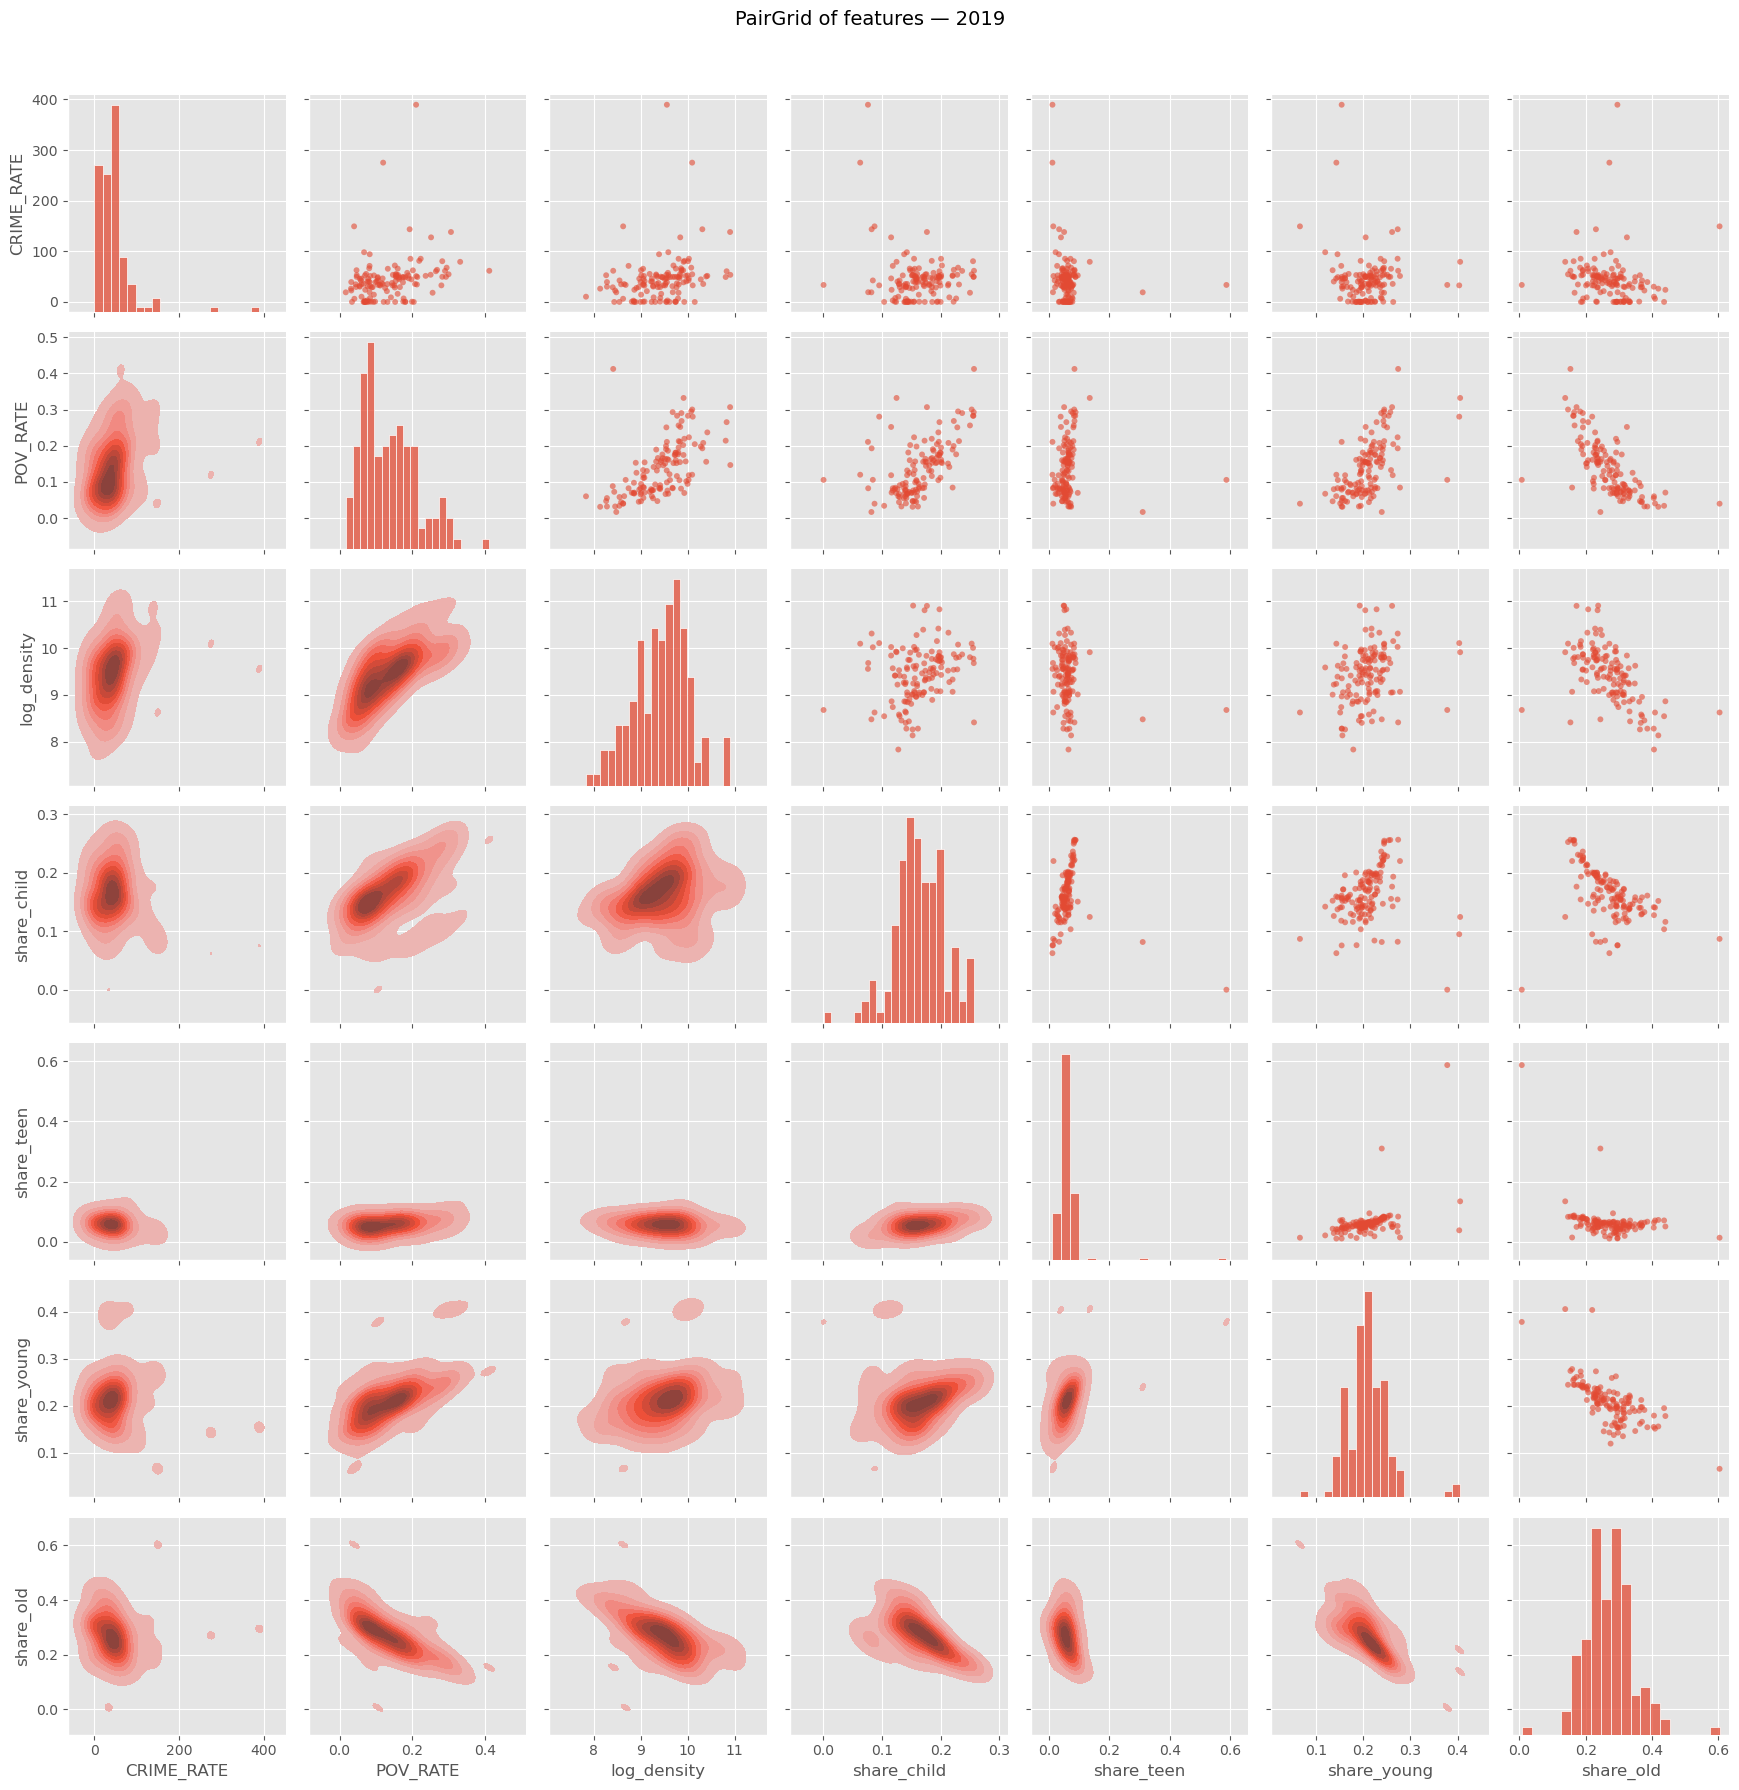

In [258]:
# To deeply explore the key features of each region in 2019 and their potential connections with crime rates, 
# we constructed a PairGrid (pairwise relation matrix) for exploratory data analysis. 
# This matrix reveals the distribution patterns of each variable 
# (such as crime rate, poverty rate, population density and age structure) through the histogram of the diagonal. 
# Meanwhile, through the kernel density plot (KDE) of the lower triangle and the scatter plot of the upper triangle, 
# the bivariate relationship and data aggregation trend between any two variables are clearly demonstrated. 
# This visualization method enables us to quickly identify potential correlations, nonlinear patterns, 
# and possible outliers, providing important insights and basis for subsequent feature engineering and modeling steps.

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

YEAR_CHOSEN = 2019

d = gdf_enriched.loc[gdf_enriched["YEAR"] == YEAR_CHOSEN].copy()

if "CRIME_RATE" not in d.columns:
    d["CRIME_RATE"] = d["CRIME_TOTAL"] / d["POP_TOTAL"] * 1000.0

# select columns to visualize
cols = [
    "CRIME_RATE",
    "POV_RATE",
    "log_density",
    "share_child",
    "share_teen",
    "share_young",
    "share_old",
]

plotdf = d[cols].dropna().copy()

g = sns.PairGrid(plotdf, diag_sharey=False, corner=False)

g.map_upper(sns.scatterplot, s=18, edgecolor="none", alpha=0.6)

g.map_lower(sns.kdeplot, fill=True, thresh=0.05, levels=10)

g.map_diag(sns.histplot, bins=20, edgecolor="white")

g.fig.suptitle(f"PairGrid of features — {YEAR_CHOSEN}", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


**The scatter and kernel density plots of various variables in 2019 generally presented several characteristics: Firstly, the CRIME_RATE was significantly skewed to the right, with a few ZCTA having a high crime rate but the majority remaining at a low level. Second, POV_RATE is positively correlated with log_density, and is also positively correlated with share_child and share_young, and significantly negatively correlated with share_old. It once again confirms a structural gradient between "poverty, high density, and youth" and "low poverty, low density, and aging". Thirdly, the Shares among different age groups typically show a mutually exclusive relationship of constitutive variables (for example, share_young and share_old show a strong negative correlation), indicating that the age structure is more of a "proportional redistribution" among different age groups rather than changing independently of each other. Overall, these graphs support the use of poverty, density, and the simplified age structure together as explanatory variables to capture the spatial differences dominated by the "youth-poverty-high density" axis.**


--- Generating plot for 2013 ---


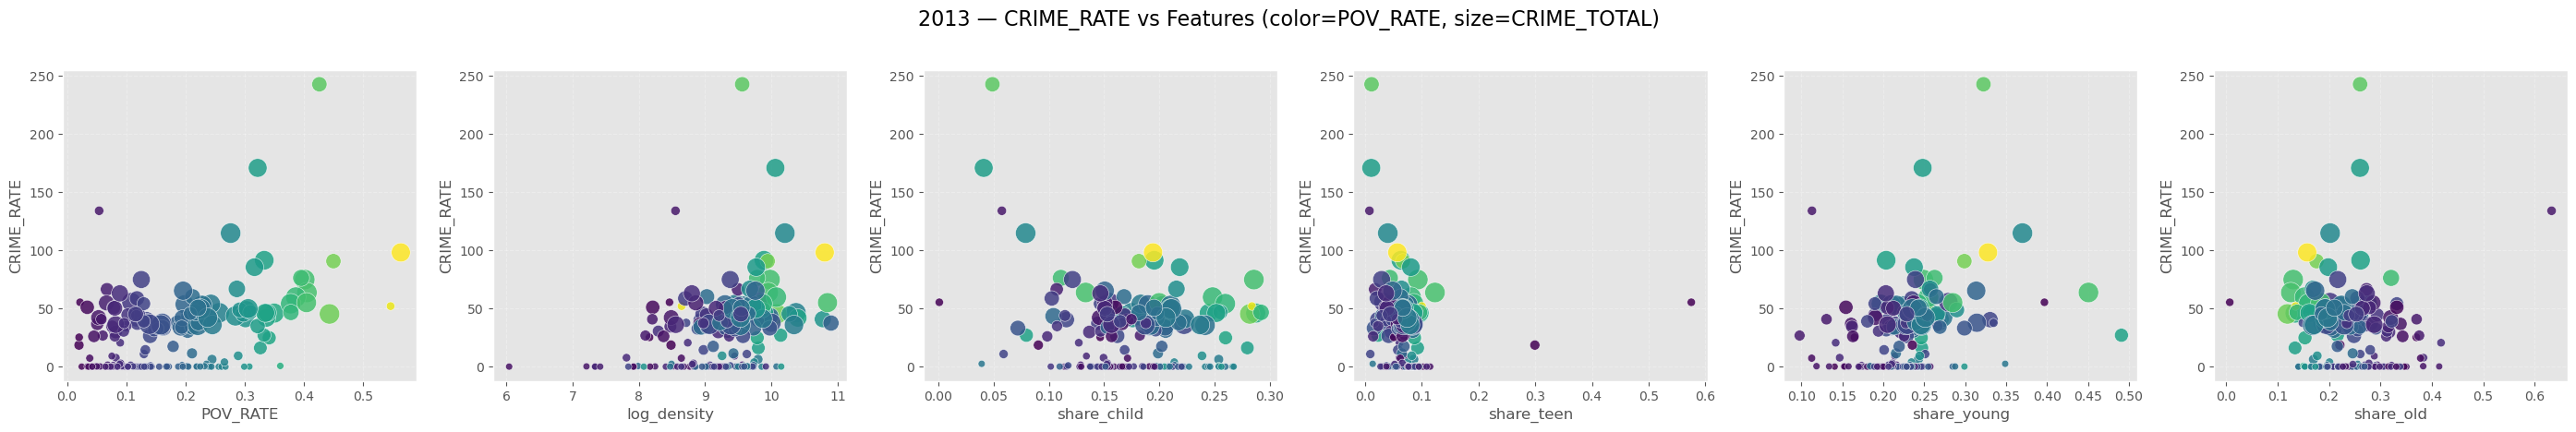

--- Generating plot for 2014 ---


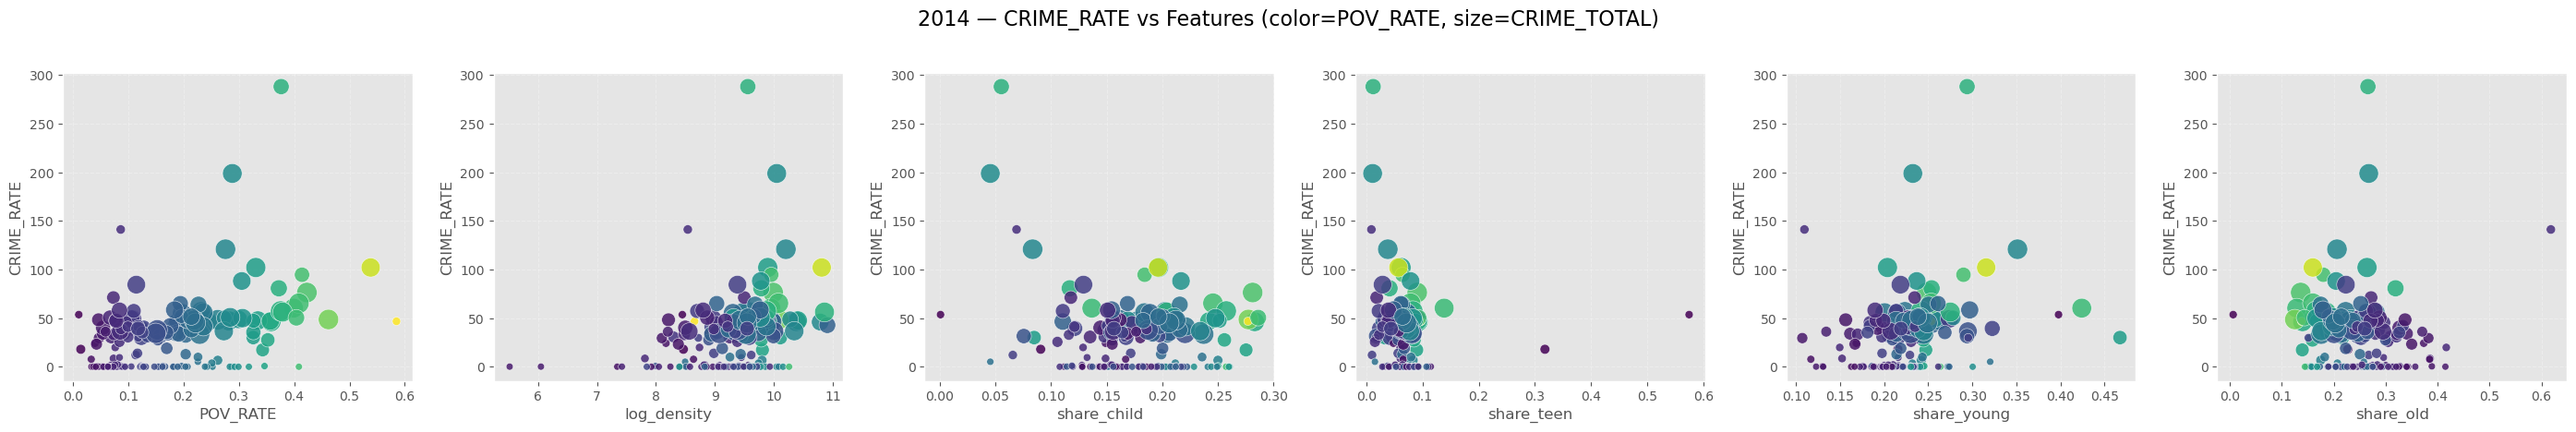

--- Generating plot for 2015 ---


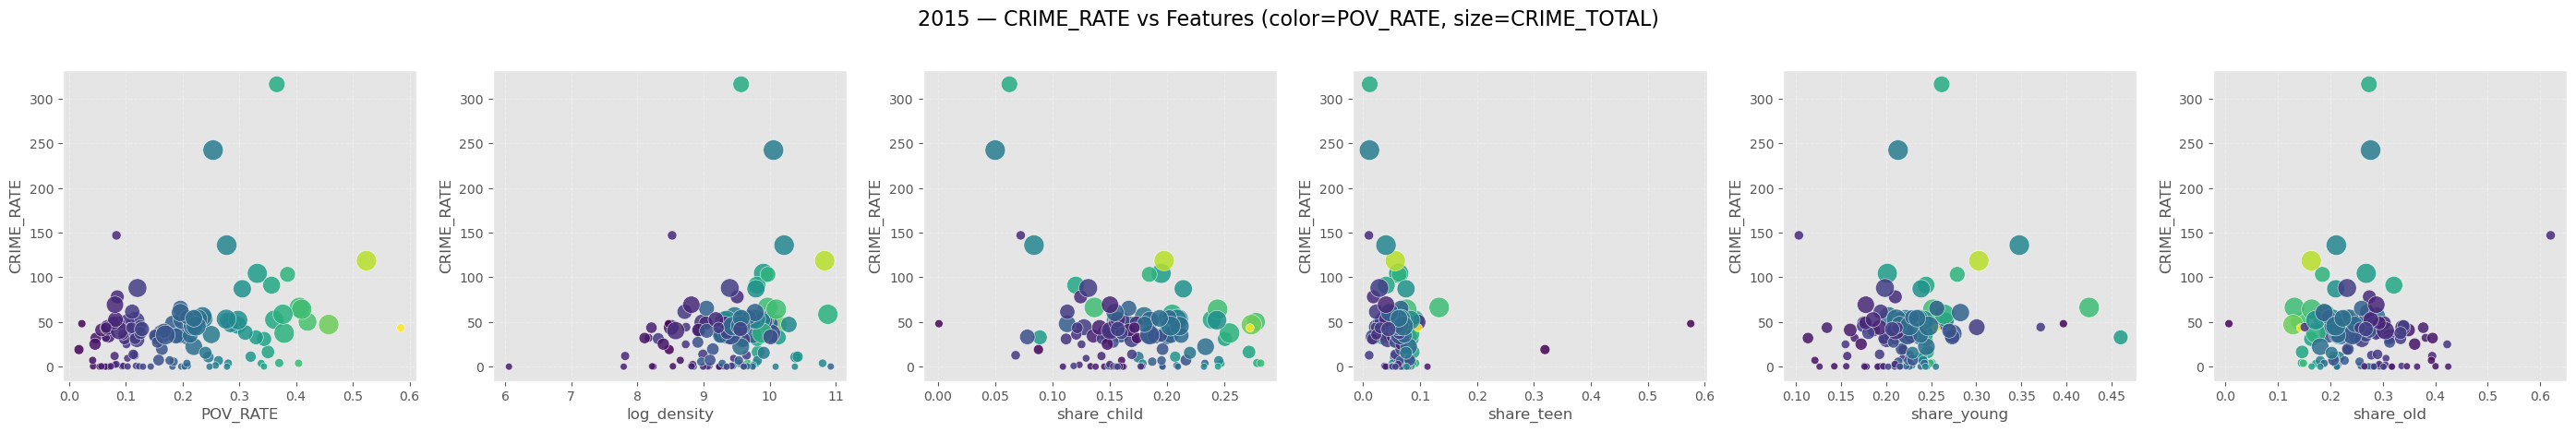

--- Generating plot for 2016 ---


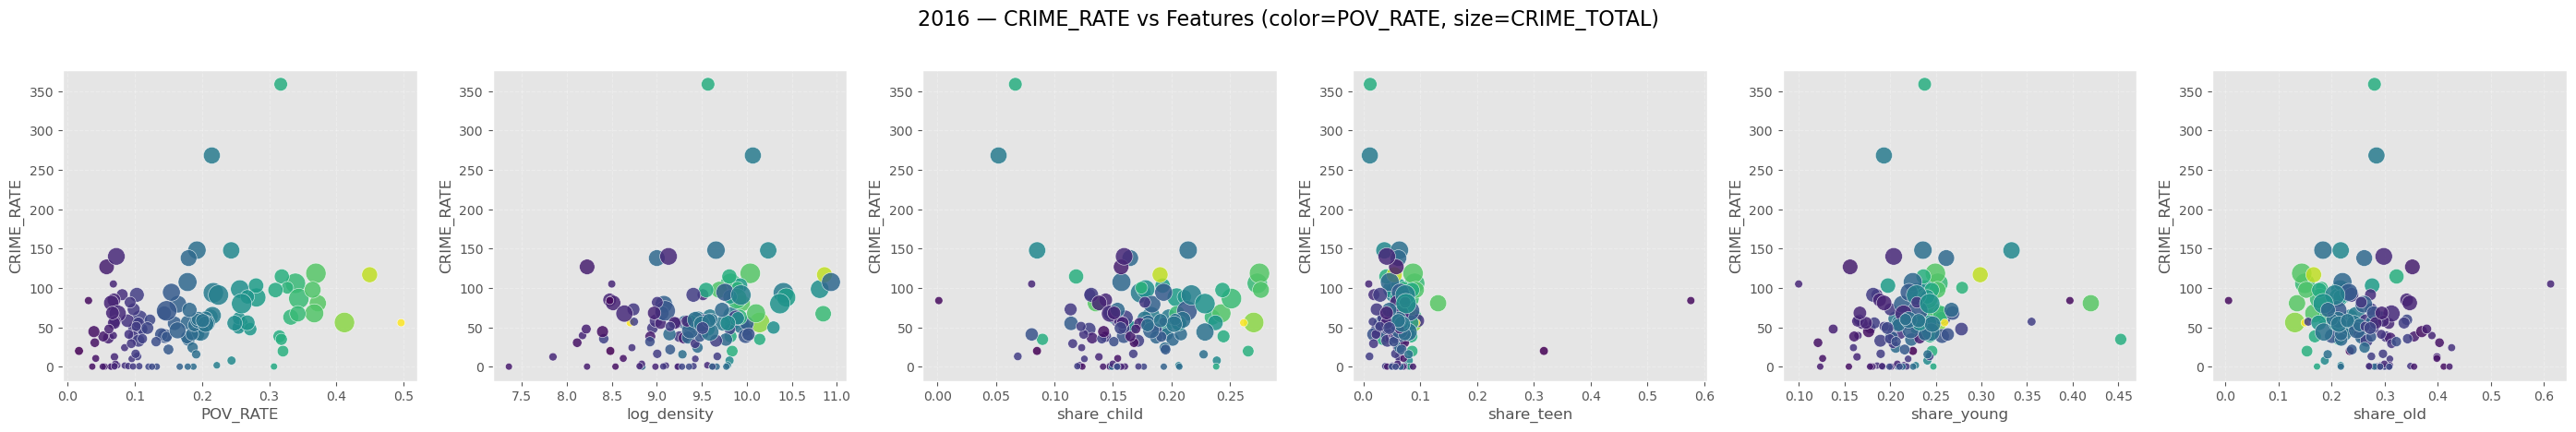

--- Generating plot for 2017 ---


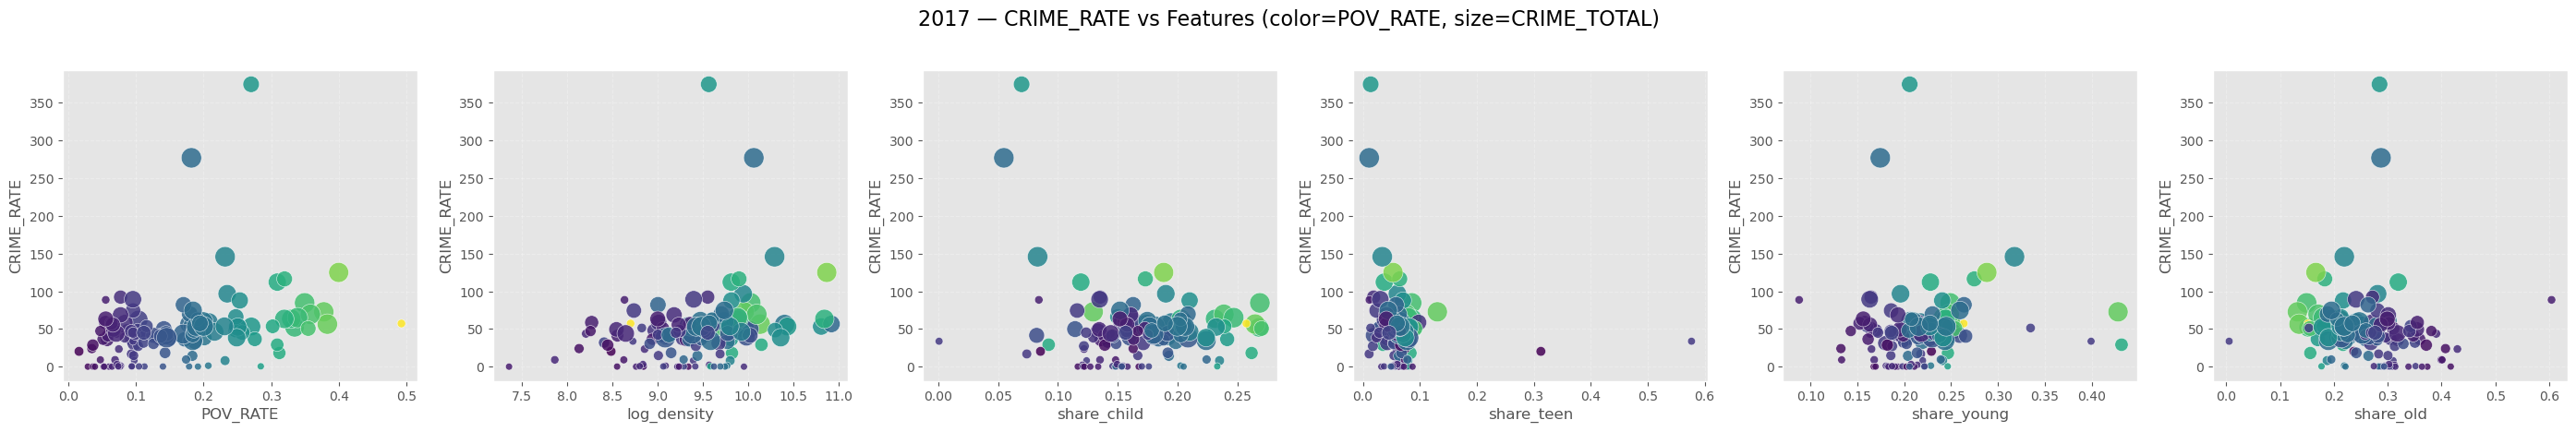

--- Generating plot for 2018 ---


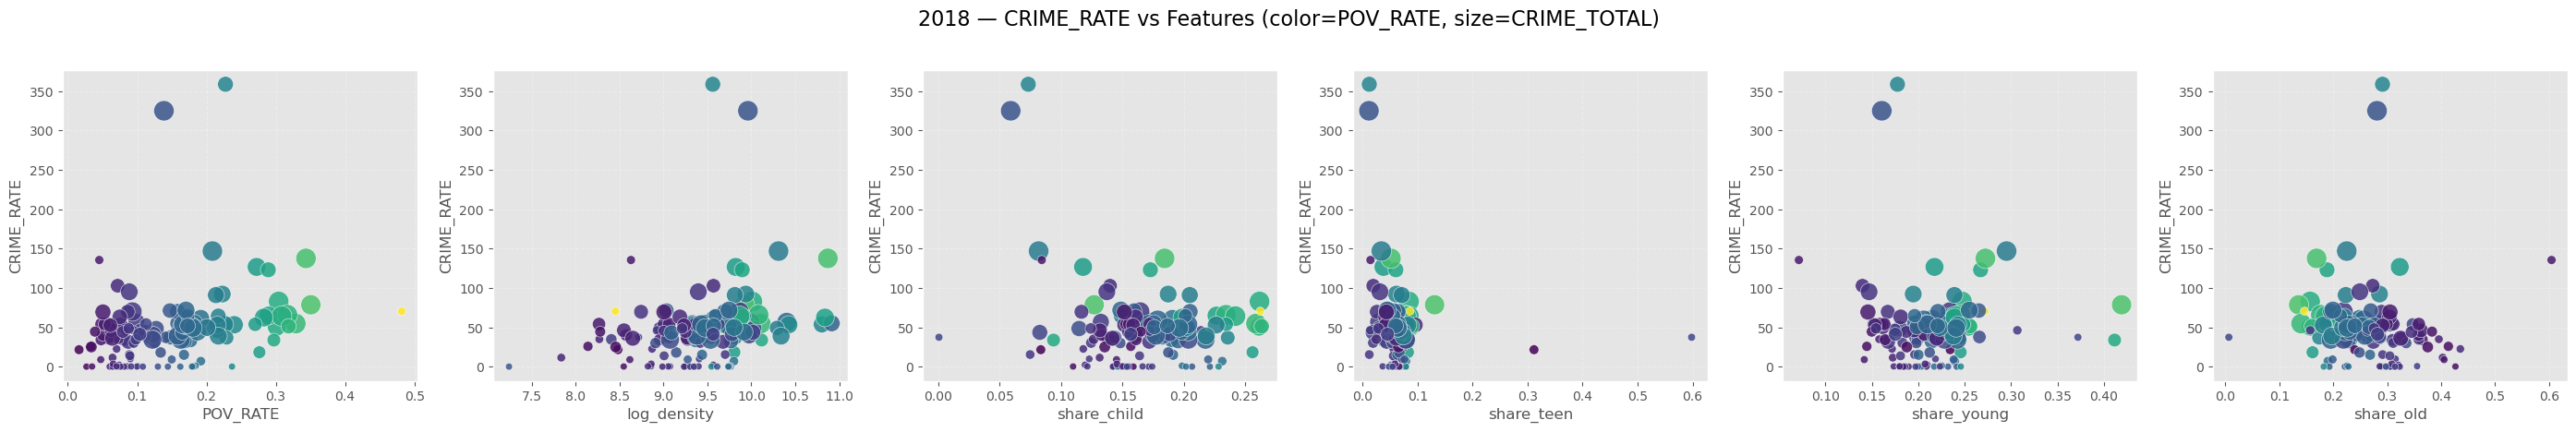

--- Generating plot for 2019 ---


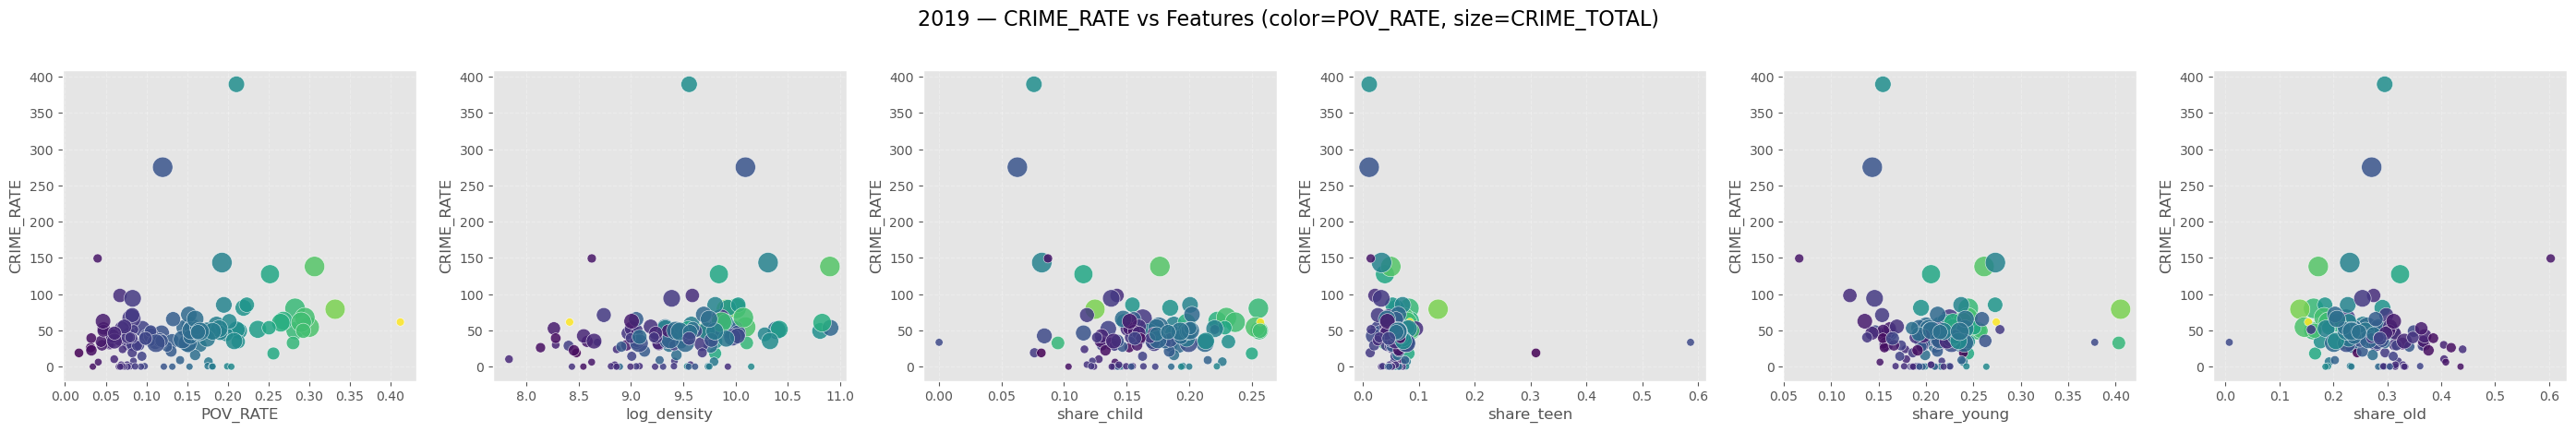

--- Generating plot for 2020 ---


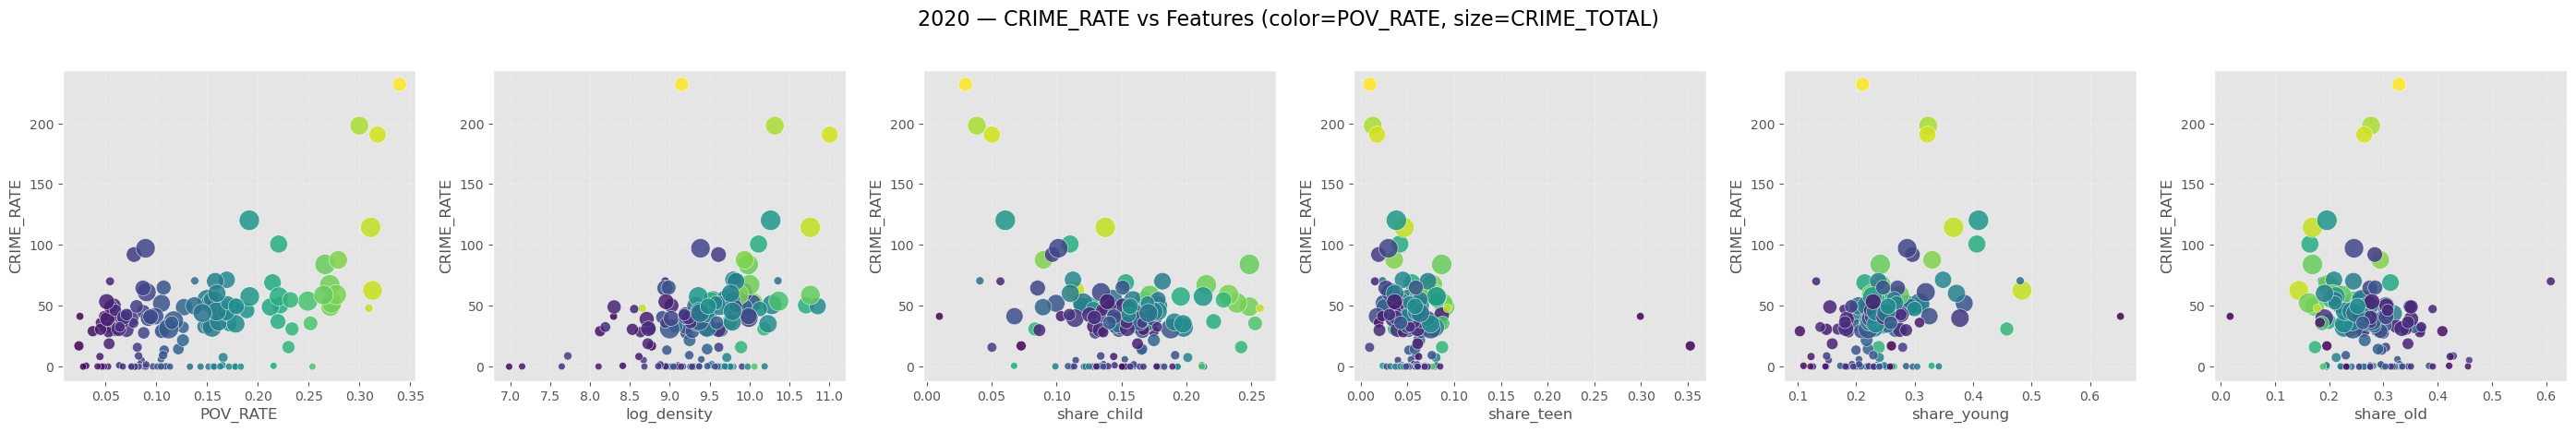

--- Generating plot for 2021 ---


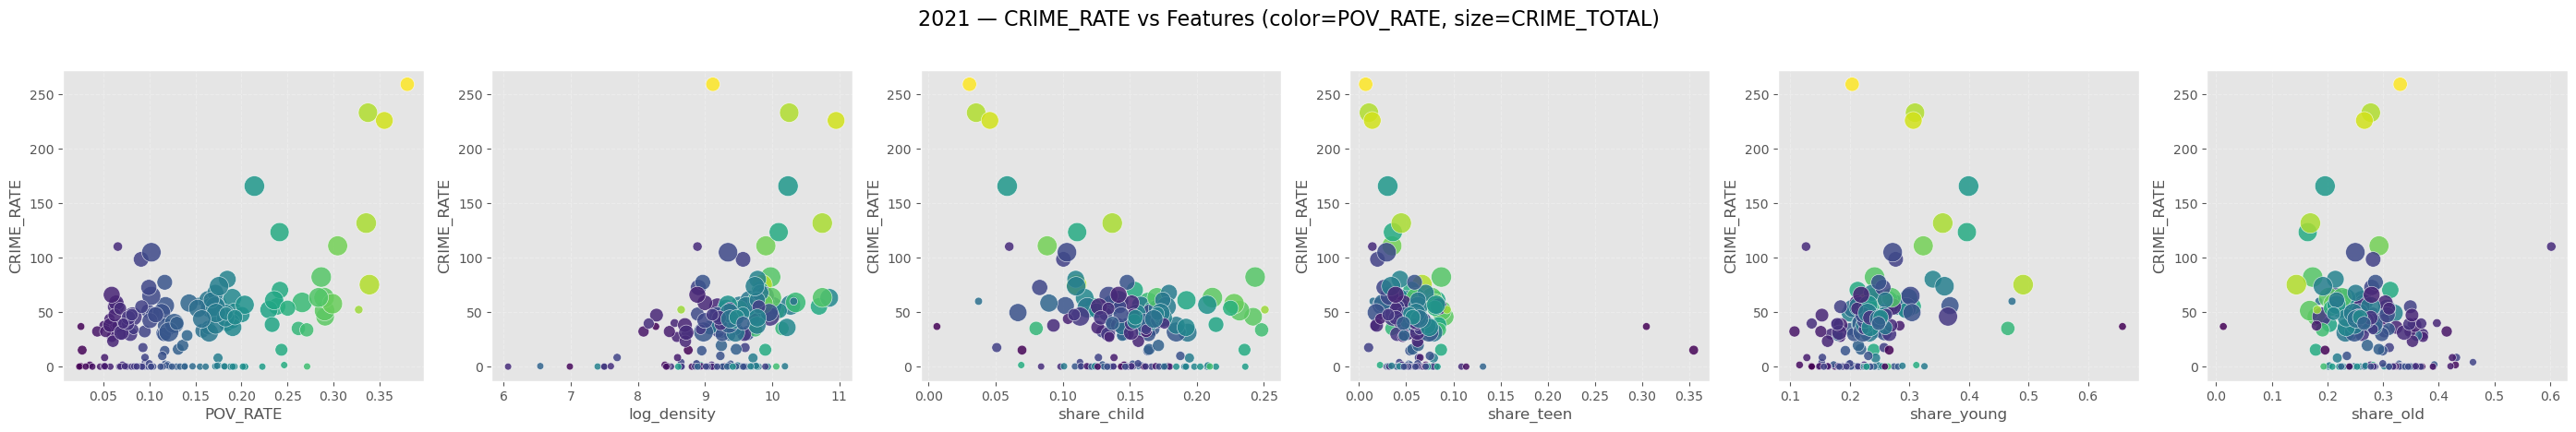

--- Generating plot for 2022 ---


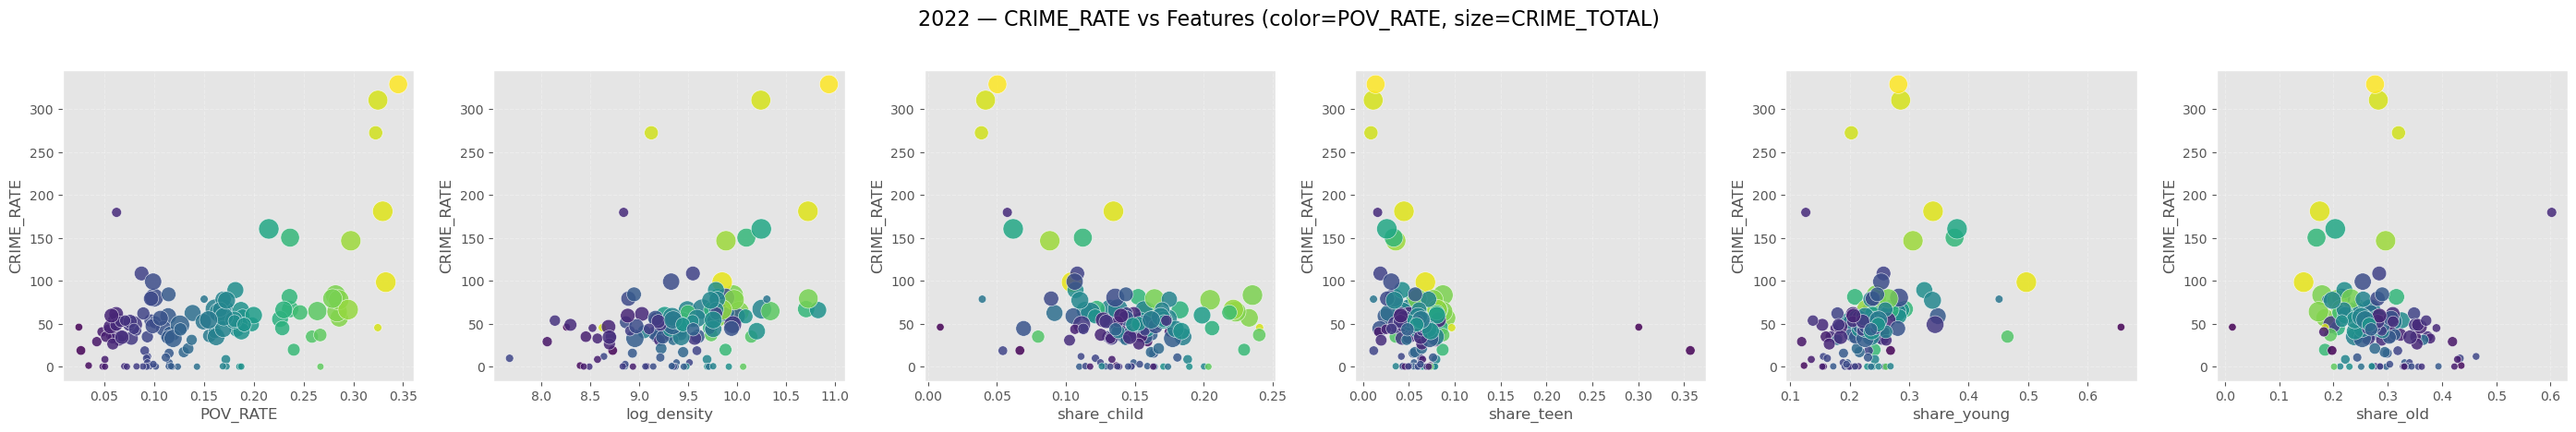

--- Generating plot for 2023 ---


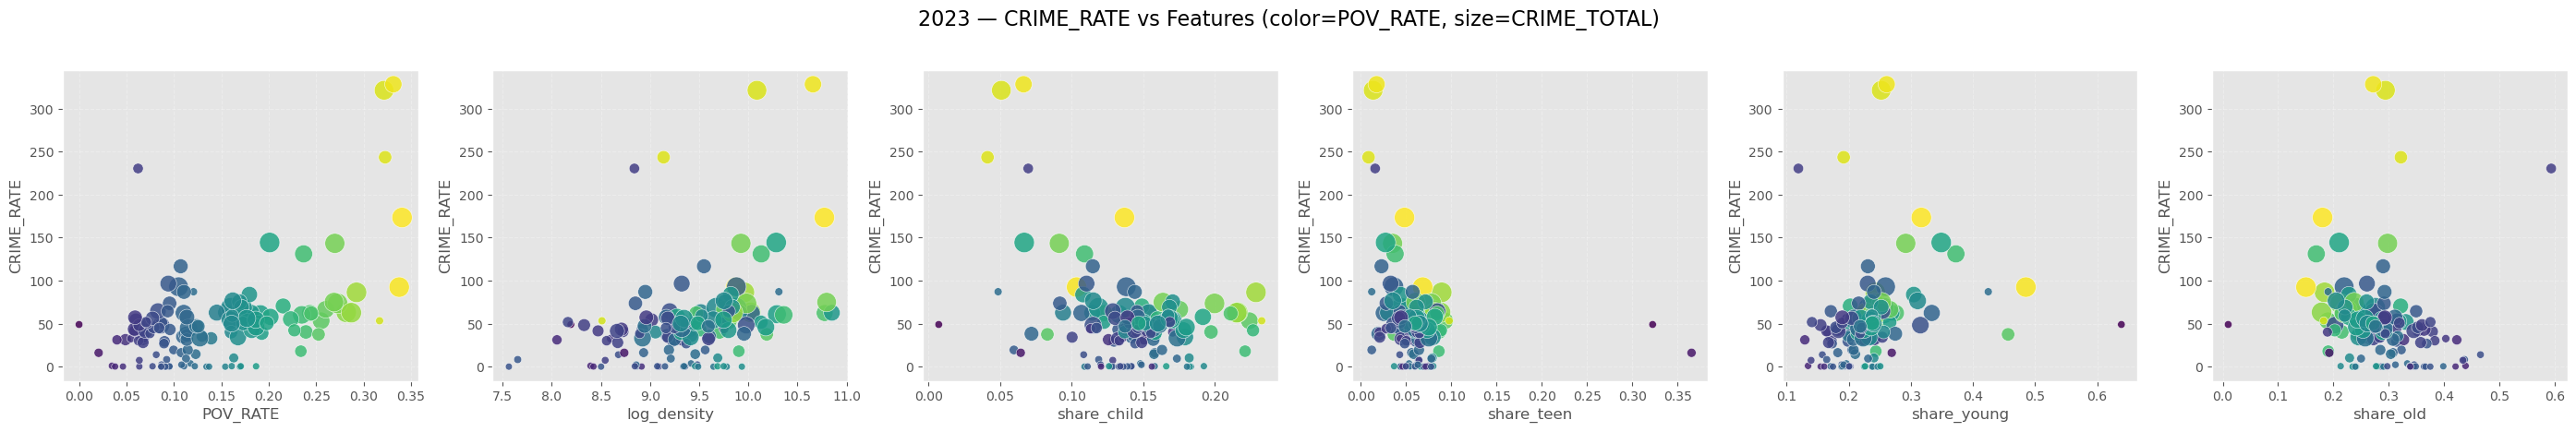

In [259]:

# The core of this code lies in creating a highly customized "miniature duplex" 
# visual grid. It systematically presents a core objective (such as CRIME_RATE) 
# side by side with multiple different predictive features 
# (such as population density, age structure, etc.) in a separate chart. 
# More advanced is that it uniformly uses "color" and "size" in all charts to encode the other two dimensions (such as poverty rate and total crime count), 
# thus allowing us to make comparisons simultaneously on all four dimensions 
# and enabling us to easily observe the evolution of these complex relationships over time (years) through loops.


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from math import ceil

def _ensure_series(df: pd.DataFrame, colname: str) -> pd.Series:
    """Return a 1-D Series for a given column name.
       If there are duplicate-named columns, take the first and warn."""
    obj = df.loc[:, colname]
    if isinstance(obj, pd.DataFrame):
        if obj.shape[1] > 1:
            print(f"[WARN] Column '{colname}' appears {obj.shape[1]} times; using the first occurrence.")
        return obj.iloc[:, 0]
    return obj

def plot_scatter_grid_bubbles(
    d: pd.DataFrame,
    features: list,
    y_col: str = "CRIME_RATE",
    color_var: str = "POV_RATE",
    size_var: str = "CRIME_TOTAL",
    ncols: int = 3,
    fig_w: float = 16,
    fig_h_per_row: float = 4.5,
    title: str = None,
):
    
    needed = set(features + [y_col, color_var, size_var])
    missing = [c for c in needed if c not in d.columns]
    if missing:
        raise ValueError(f"Missing columns in DataFrame: {missing}")

    # --- Build a clean numeric frame for shared normalizers (just color/size/y)
    base = pd.DataFrame({
        y_col: pd.to_numeric(_ensure_series(d, y_col), errors="coerce"),
        color_var: pd.to_numeric(_ensure_series(d, color_var), errors="coerce"),
        size_var: pd.to_numeric(_ensure_series(d, size_var), errors="coerce"),
    })
    base = base.replace([np.inf, -np.inf], np.nan)

    # color normalization
    c_vals = base[color_var].to_numpy(dtype=float)
    vmin, vmax = np.nanmin(c_vals), np.nanmax(c_vals)
    if not np.isfinite(vmin) or not np.isfinite(vmax) or np.isclose(vmin, vmax):
        vmin = 0.0 if not np.isfinite(vmin) else float(vmin) - 1e-9
        vmax = 1.0 if not np.isfinite(vmax) else float(vmax) + 1e-9
    norm = Normalize(vmin=float(vmin), vmax=float(vmax))
    cmap = cm.get_cmap("viridis")

    s_vals = base[size_var].to_numpy(dtype=float)
    sp5, sp95 = np.nanpercentile(s_vals, [5, 95])
    if not np.isfinite(sp5) or not np.isfinite(sp95) or np.isclose(sp5, sp95):
        sp5, sp95 = np.nanmin(s_vals), np.nanmax(s_vals)
    def scale_size(x):
        x = np.clip(x, sp5, sp95)
        return 30.0 + 220.0 * (x - sp5) / (sp95 - sp5 + 1e-12)

    # --- Figure layout
    n = len(features)
    nrows = ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h_per_row * nrows))
    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = np.array([axes])
    axes = axes.copy()

    for i, feat in enumerate(features):
        r, c = divmod(i, ncols)
        ax = axes[r, c]

        # Build a sub-DataFrame with ONLY these four columns and clean there
        sub = pd.DataFrame({
            "x": pd.to_numeric(_ensure_series(d, feat), errors="coerce"),
            "y": base[y_col],      
            "col": base[color_var], 
            "siz": base[size_var],   
        })
        sub = sub.replace([np.inf, -np.inf], np.nan).dropna()

        if sub.empty:
            ax.set_title(f"{feat} (no data)")
            ax.axis("off")
            continue

        x = sub["x"].to_numpy(dtype=float)
        y = sub["y"].to_numpy(dtype=float)
        colors = cmap(norm(sub["col"].to_numpy(dtype=float)))
        sizes  = scale_size(sub["siz"].to_numpy(dtype=float))

        ax.scatter(x, y, s=sizes, c=colors, edgecolor="white", linewidth=0.4, alpha=0.85)
        ax.set_xlabel(feat)
        ax.set_ylabel(y_col)
        ax.grid(True, linestyle="--", alpha=0.3)

    total_panels = nrows * ncols
    for j in range(n, total_panels):
        r, c = divmod(j, ncols)
        axes[r, c].axis("off")

    if title:
        fig.suptitle(title, fontsize=16, y=1.03)
    plt.tight_layout()
    plt.show()



features = ["POV_RATE", "log_density", "share_child", "share_teen", "share_young", "share_old"]

for year in YEARS:
    print(f"--- Generating plot for {year} ---")
    df_year = gdf_enriched[gdf_enriched["YEAR"] == year].copy()
    
    if df_year.empty:
        print(f"Skipping {year}, no data available.")
        continue
    
    plot_scatter_grid_bubbles(
        d=df_year,
        features=features,
        y_col="CRIME_RATE",
        color_var="POV_RATE",    
        size_var="CRIME_TOTAL",   
        ncols=6,                 
        fig_w=28,             
        fig_h_per_row=4.5,
        title=f"{year} — CRIME_RATE vs Features (color=POV_RATE, size=CRIME_TOTAL)"
    )

**These annual bubble charts as a whole present a relatively stable pattern from 2013 to 2023: in any given year, the ZCTAs with high crime rates and high total crime volumes are mainly concentrated in areas with higher poverty rates and greater population density (the bubbles move to the right, upwards, and are more yellowish in color and larger in size). The relationship with age structure is relatively weak: in regions with a high proportion of child/teen/young, only a few points correspond to a high crime rate, while when share_old is high, the overall crime rate is relatively low. High crime rates and large bubbles are more often found in combinations where the proportion of the elderly is relatively low, the proportion of middle-aged and young people is relatively high, and the poverty rate is relatively high. Overall, the graphs on the time series reinforce the previous conclusion: the high crime hotspots in LA have long been associated with the community characteristics of "high poverty + high density + relatively young age", and the role of age structure is more reflected in the different risk combinations formed when superimposed with poverty and density.**

### Bivariate Analysis


#### Especially on Bivariate: POV × Density， Take 2019 as example, and more years can be explored

**Below code defines a function for creating an interactive bivariate hierarchical statistical map. Its core value lies in not mapping the poverty rate or population density separately, but combining the data of both (each divided into low, medium and high levels) into a 3x3 matrix and assigning specific colors to these nine combinations (such as "high poverty and high density" or "low poverty and high density"). The final generated HTML map enables you to clearly see the spatial interrelationship and aggregation pattern of the two variables at a glance, and is equipped with custom legends and hover prompts.**

In [260]:
import geopandas as gpd
import folium
import numpy as np

def make_bivariate_map(gdf_year, var_x='POV_RATE', var_y='log_density',
                       title='Bivariate: POV × Density',
                       html_out='map_bivariate.html'):
    """
    Interactive bivariate (3×3) choropleth combining two variables.
    X-axis = var_x tertiles (low→high), Y-axis = var_y tertiles (low→high).
    """
    gdf = gdf_year.dropna(subset=[var_x, var_y]).copy()
    if gdf.crs is None or gdf.crs.to_epsg() != 4326:
        gdf = gdf.to_crs(4326)

    # Tertiles (0,1,2)
    qx = np.quantile(gdf[var_x], [1/3, 2/3])
    qy = np.quantile(gdf[var_y], [1/3, 2/3])

    def terciles(series, qs):
        return np.select(
            [series <= qs[0], (series > qs[0]) & (series <= qs[1]), series > qs[1]],
            [0, 1, 2]
        )

    gdf['x_bin'] = terciles(gdf[var_x].to_numpy(), qx)
    gdf['y_bin'] = terciles(gdf[var_y].to_numpy(), qy)
    gdf['bi_code'] = gdf['x_bin'] * 3 + gdf['y_bin']   # 0..8

    # 3×3 color matrix (row = x low→high, col = y low→high)
    color_matrix = [
        ['#e8e8e8', '#b8d6be', '#7fb8ad'],
        ['#cbb8d6', '#a5add3', '#5698b9'],
        ['#b07aa1', '#8c8db5', '#4f6d8a']
    ]
    code2color = {i*3 + j: color_matrix[i][j] for i in range(3) for j in range(3)}

    center = [
        gdf.geometry.representative_point().y.mean(),
        gdf.geometry.representative_point().x.mean()
    ]
    m = folium.Map(location=center, zoom_start=10, tiles='cartodbpositron')

    def style_fn(feat):
        code = feat['properties'].get('bi_code')
        c = code2color.get(int(code), '#cccccc') if code is not None else '#cccccc'
        return {'fillColor': c, 'color':'#ffffff', 'weight':0.5, 'fillOpacity':0.9}

    tooltip_fields = [c for c in ['ZCTA', 'YEAR', var_x, var_y, 'x_bin', 'y_bin'] if c in gdf.columns]
    tooltip = folium.features.GeoJsonTooltip(
        fields=tooltip_fields,
        aliases=['ZCTA','Year',var_x,var_y,'POV tertile','Density tertile'],
        localize=True, sticky=True
    )

    folium.GeoJson(gdf, name=title, style_function=style_fn, tooltip=tooltip).add_to(m)


    rows_html = []
    for i in range(2, -1, -1):
        cells = ''.join([f'<td style="width:18px;height:18px;background:{color_matrix[i][j]};border:1px solid #999"></td>'
                         for j in range(3)])
        rows_html.append(f'<tr>{cells}</tr>')
    rows_html = ''.join(rows_html)

    legend_html = f"""
    <div style="position: fixed; bottom: 18px; left: 18px; z-index: 9999; background: white; padding: 10px 12px; border:1px solid #aaa; box-shadow: 0 1px 3px rgba(0,0,0,.2);">
      <div style="font-weight:600; margin-bottom:6px">{title}</div>
      <table style="border-collapse: collapse;">{rows_html}</table>
      <div style="margin-top:6px; font-size:12px">
        X = {var_x} (left→right: low→high)<br/>
        Y = {var_y} (bottom→top: low→high)
      </div>
    </div>
    """
    m.get_root().html.add_child(folium.Element(legend_html))
    folium.LayerControl(collapsed=False).add_to(m)
    m.save(html_out)
    print(f"Saved: {html_out}")
    return m

# ===== Example =====
gdf_2019 = gdf_enriched[gdf_enriched['YEAR'] == 2019].copy()
make_bivariate_map(
    gdf_2019,
    var_x='POV_RATE', var_y='log_density',
    title='2019 — POV × log_density (bivariate 3×3)',
    html_out='map_2019_bivariate_pov_density.html'
)


Saved: map_2019_bivariate_pov_density.html


**This 2019 bivariate map, which combines the poverty rate (X-axis) and population density (Y-axis), shows a very clear spatial differentiation within LA: The western coast, valleys and other areas are mostly characterized by low poverty and low to medium density (light-colored blocks), while in the central and southern regions and the inner city areas, dark blocks of high poverty and high density are concentrated, forming a "high poverty - high density corridor" extending along the inner city and the southern part of LA. At the same time, a few high-poverty and low-density grids can also be seen on the outskirts of the city, indicating that although the population in some far suburban communities is not crowded, their economic situation remains unfavorable. Overall, this map visualizes the "poverty - density - spatial gradient" seen in the previous statistics into a very intuitive geographical pattern, and also provides a basis for the subsequent spatial comparison of these areas with crime hotspots.**

In [261]:
import geopandas as gpd


gdf = gpd.read_file("./Outputs/GeoData_all_years.gpkg", layer="zcta_years")
gdf.to_file("./Outputs/la_zcta_years.geojson", driver="GeoJSON")


In [262]:
import pandas as pd

pd.read_parquet("./Outputs/tableau/ols_residuals.parquet").to_csv("./Outputs/tableau/ols_residuals.csv", index=False)
pd.read_parquet("./Outputs/tableau/gwr_coeffs.parquet").to_csv("./Outputs/tableau/gwr_coeffs.csv", index=False)
print("Saved: ols_residuals.csv, gwr_coeffs.csv")


Saved: ols_residuals.csv, gwr_coeffs.csv


**The below script exports a city-clipped set of tables for Tableau:**


    1.la_zcta_years.geojson – Base spatial layer with ZCTA polygons and yearly socio-economic and crime attributes. This file is used for all mapping and as the join key for the model outputs.


    2.ols_summary.csv – Year-level OLS diagnostics (e.g., R2R^2R2, adjusted R2R^2R2, AIC, BIC, residual statistics), supporting comparison of global model performance over time.


    3.ols_residuals.csv – ZCTA-level fitted values and residuals from the OLS models. In Tableau this is used to map over- and under-prediction, build residual histograms, and check spatial patterns.


    4.resid_ranges.csv – Pre-defined residual classes and labels, so residual maps can use a consistent legend and be compared across years.


    5.gwr_coeffs.csv – Local GWR coefficients (and local fit metrics where available) for each ZCTA, year, and predictor. This table underpins the spatially varying coefficient maps and local pattern exploration.


    6.model_kpis.csv – Model-level KPIs (e.g., OLS vs GWR R2R^2R2, AIC/AICc, residual variance) used to summarize and compare model performance in dashboard views.


    7.ols_coeffs.csv – “Wide” OLS coefficient table with one row per year and one column per predictor, convenient for coefficient comparison in tables or heatmaps.


    8.ols_coeffs_long.csv – “Long” version of the same coefficients (year–variable–estimate), designed for line charts and small multiples that track changes in global effects over time.


**Together, these outputs allow Tableau to support correlation analysis (via the attributes in la_zcta_years.geojson), global OLS analysis and diagnostics (using ols_summary, ols_residuals, and the OLS coefficient tables), local GWR analysis (using gwr_coeffs), and clustering/segmentation of neighborhoods based on socio-economic profiles, residual patterns, and local model coefficients.**

In [263]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
from pathlib import Path
from shapely.geometry.base import BaseGeometry
from shapely.ops import unary_union
from statsmodels.api import OLS, add_constant
from sklearn.metrics import mean_squared_error, mean_absolute_error
from libpysal.weights import Queen, KNN
from esda.moran import Moran, Moran_Local
from mgwr.gwr import GWR, Gaussian
from mgwr.sel_bw import Sel_BW

pd.set_option("display.max_columns", 200)

ATTR_CSV = "./Data/filtered_crime_with_census.csv"
ZCTA_BOUNDARY = "./Data/la_zcta5_2020.zip"
CITY_BOUNDARY_PATH = "./Data/la_city_zcta.geojson"
CLIP_TO_CITY = True

COLS = {
    "zcta_from_key": "ZCTA_YEAR_KEY",
    "year": "YEAR",
    "crime_total": "CRIME_TOTAL",
    "pop_total": "POP_TOTAL",
    "pov_rate": "POV_RATE",
    "pop_density": "POP_DENSITY",
}

YEARS = list(range(2013, 2024))
METRIC_EPSG = 3310
WEIGHTS_MODE = "queen"
KNN_K = 6
POP_MIN_FLAG = 2000
AREA_MIN_SQKM_FLAG = 0.5

OUT_GPKG = "./Outputs/GeoData_all_years.gpkg"
OUT_DIR = Path("./Outputs/tableau"); OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_GEOJSON = OUT_DIR / "la_zcta_years.geojson"
OUT_OLS_SUMMARY = OUT_DIR / "ols_summary.csv"
OUT_OLS_RESIDUALS = OUT_DIR / "ols_residuals.csv"
OUT_RESID_RANGES = OUT_DIR / "resid_ranges.csv"
OUT_GWR_COEFFS = OUT_DIR / "gwr_coeffs.csv"
OUT_MODEL_KPIS = OUT_DIR / "model_kpis.csv"
OUT_OLS_COEFFS_WIDE = OUT_DIR / "ols_coeffs.csv"
OUT_OLS_COEFFS_LONG = OUT_DIR / "ols_coeffs_long.csv"
OUT_GWR_BY_YEAR_CSV = OUT_DIR / "gwr_outputs_by_year.csv"

def _read_any(path_pattern: str) -> gpd.GeoDataFrame:
    import glob, os
    matches = glob.glob(path_pattern) if any(ch in path_pattern for ch in "*?[]") else [path_pattern]
    if not matches:
        raise FileNotFoundError(f"Boundary not found: {path_pattern}")
    if len(matches) > 1:
        print(f"[WARN] Multiple matched; using: {matches[0]}")
    path = matches[0]
    return gpd.read_file(path)

def _clean_geom(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    g = gdf[gdf.geometry.notna()].copy()
    try:
        from shapely.validation import make_valid
        g["geometry"] = g["geometry"].apply(lambda x: make_valid(x) if not x.is_valid else x)
    except Exception:
        g["geometry"] = g.buffer(0)
    def _is_area(geom: BaseGeometry) -> bool:
        return (geom is not None) and (not geom.is_empty) and (geom.geom_type in ("Polygon","MultiPolygon"))
    g = g[g.geometry.apply(_is_area)].copy()
    return g

def load_and_clean_attributes(csv_path: str, colmap: dict) -> pd.DataFrame:
    df_raw = pd.read_csv(csv_path)
    df_raw.columns = [c.strip() for c in df_raw.columns]
    df = df_raw.copy()

    zcta_col_direct = colmap.get("zcta")
    zcta_from_key   = colmap.get("zcta_from_key")
    if zcta_col_direct and zcta_col_direct in df.columns:
        zc = df[zcta_col_direct].astype(str).str.extract(r"(\d{5})", expand=False)
        df["ZCTA"] = zc.str.zfill(5)
    elif zcta_from_key and zcta_from_key in df.columns:
        key = df[zcta_from_key].astype(str)
        zc = key.str.extract(r"^\D*?(\d{5})", expand=False).fillna(key.str.extract(r"(\d{5})", expand=False))
        df["ZCTA"] = zc.str.zfill(5)
    else:
        raise ValueError("Provide COLS['zcta'] or COLS['zcta_from_key'].")

    req = ["year","crime_total","pop_total","pov_rate","pop_density"]
    miss = [colmap[k] for k in req if colmap[k] not in df.columns]
    if miss:
        raise ValueError(f"Missing required columns: {miss}")

    df[colmap["year"]] = pd.to_numeric(df[colmap["year"]], errors="coerce").astype("Int64")
    df.rename(columns={
        colmap["year"]: "YEAR",
        colmap["crime_total"]: "CRIME_TOTAL",
        colmap["pop_total"]: "POP_TOTAL",
        colmap["pov_rate"]: "POV_RATE",
        colmap["pop_density"]: "POP_DENSITY",
    }, inplace=True)

    for c in ["CRIME_TOTAL","POP_TOTAL","POV_RATE","POP_DENSITY"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
        df.loc[df[c] < 0, c] = np.nan

    df = df.dropna(subset=["ZCTA","YEAR","POP_TOTAL"]).copy()
    df["YEAR"] = df["YEAR"].astype(int)
    return df

def load_boundaries(boundary_path: str) -> gpd.GeoDataFrame:
    from pathlib import Path
    from zipfile import ZipFile
    import fiona
    p = Path(boundary_path)
    if p.suffix.lower() == ".zip":
        with ZipFile(p) as zf:
            shp_names = [n for n in zf.namelist() if n.lower().endswith(".shp")]
            if not shp_names: raise FileNotFoundError(f"No .shp in {p}")
            uri = f"zip://{p.resolve()}!{shp_names[0]}"
        gdf = gpd.read_file(uri)
    elif p.suffix.lower() == ".shp" and not p.with_suffix(".shx").exists():
        with fiona.Env(SHAPE_RESTORE_SHX="YES"):
            gdf = gpd.read_file(boundary_path)
    else:
        gdf = gpd.read_file(boundary_path)

    zcol = None
    for cand in ["ZCTA","ZCTA5CE20","ZCTA5CE10","GEOID20","GEOID10","GEOID","ZCTA5","ZIPCODE"]:
        if cand in gdf.columns:
            zcol = cand; break
    if zcol is None:
        raise ValueError(f"No ZCTA code column. Columns: {gdf.columns.tolist()}")

    gdf["ZCTA"] = gdf[zcol].astype(str).str.extract(r"(\d{5})", expand=False).str.zfill(5)
    gdf = gdf.dissolve(by="ZCTA", as_index=False)

    try:
        from shapely.validation import make_valid
        gdf.loc[~gdf.is_valid, "geometry"] = gdf.loc[~gdf.is_valid, "geometry"].apply(make_valid)
    except Exception:
        gdf.loc[~gdf.is_valid, "geometry"] = gdf.loc[~gdf.is_valid, "geometry"].buffer(0)

    gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty].copy()
    return gdf[["ZCTA","geometry"]]

def join_attributes_to_geometry(df_attr: pd.DataFrame, gdf_boundary: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    gdf = gdf_boundary.merge(df_attr, on="ZCTA", how="inner")
    return gpd.GeoDataFrame(gdf, geometry="geometry", crs=gdf_boundary.crs)

def project_to_metric_crs(gdf: gpd.GeoDataFrame, epsg: int) -> gpd.GeoDataFrame:
    if gdf.crs is None:
        gdf = gdf.set_crs(4326, allow_override=True)
    return gdf if gdf.crs.to_epsg() == epsg else gdf.to_crs(epsg)

def add_qc_flags(gdf_proj: gpd.GeoDataFrame,
                 pop_min_flag=POP_MIN_FLAG,
                 area_min_sqkm_flag=AREA_MIN_SQKM_FLAG) -> gpd.GeoDataFrame:
    out = gdf_proj.copy()
    out["area_sqkm"] = out.geometry.area / 1e6
    out["flag_small_pop"] = (out["POP_TOTAL"] < pop_min_flag).fillna(False)
    out["flag_tiny_geom"] = (out["area_sqkm"] < area_min_sqkm_flag).fillna(False)
    return out

def _check_age_columns(df: pd.DataFrame):
    needed = [
        "POP_TOTAL",
        "POP_AGE_0_4","POP_AGE_5_9","POP_AGE_10_14",
        "POP_AGE_15_17","POP_AGE_18_19",
        "POP_AGE_20_24","POP_AGE_25_29","POP_AGE_30_34",
        "POP_AGE_35_44","POP_AGE_45_54",
        "POP_AGE_55_64","POP_AGE_65_74","POP_AGE_75_84","POP_AGE_85_100"
    ]
    miss = [c for c in needed if c not in df.columns]
    if miss: raise ValueError(f"Missing age columns: {miss}")

def build_age_shares(df: pd.DataFrame) -> pd.DataFrame:
    g = df.copy(); _check_age_columns(g)
    g["age_child_cnt"] = g[["POP_AGE_0_4","POP_AGE_5_9","POP_AGE_10_14"]].fillna(0).sum(axis=1)
    g["age_teen_cnt"]  = g[["POP_AGE_15_17","POP_AGE_18_19"]].fillna(0).sum(axis=1)
    g["age_young_cnt"] = g[["POP_AGE_20_24","POP_AGE_25_29","POP_AGE_30_34"]].fillna(0).sum(axis=1)
    g["age_mid_cnt"]   = g[["POP_AGE_35_44","POP_AGE_45_54"]].fillna(0).sum(axis=1)
    g["age_old_cnt"]   = g[["POP_AGE_55_64","POP_AGE_65_74","POP_AGE_75_84","POP_AGE_85_100"]].fillna(0).sum(axis=1)
    den = g["POP_TOTAL"].replace({0: np.nan})
    g["share_child"] = (g["age_child_cnt"]/den).clip(0,1)
    g["share_teen"]  = (g["age_teen_cnt"]/den).clip(0,1)
    g["share_young"] = (g["age_young_cnt"]/den).clip(0,1)
    g["share_mid"]   = (g["age_mid_cnt"]/den).clip(0,1)
    g["share_old"]   = (g["age_old_cnt"]/den).clip(0,1)
    return g

def normalize_pov_rate(df: pd.DataFrame, col="POV_RATE", mode="auto") -> pd.DataFrame:
    g = df.copy()
    mx = pd.to_numeric(g[col], errors="coerce").max()
    if mode == "auto" and pd.notna(mx) and mx > 1.5:
        g[col] = g[col] / 100.0
    elif mode == "01":
        g[col] = g[col] / 100.0
    elif mode == "0_100":
        pass
    else:
        if pd.notna(mx) and mx > 1.5: g[col] = g[col]/100.0
    return g

def add_density_and_rate(df: pd.DataFrame, rate_scale=1000.0) -> pd.DataFrame:
    g = df.copy()
    if "POP_DENSITY" in g.columns:
        g["log_density"] = np.log1p(pd.to_numeric(g["POP_DENSITY"], errors="coerce"))
    else:
        gm = g.to_crs(METRIC_EPSG)
        area_km2 = gm.geometry.area / 1e6
        g["density_fallback"] = g["POP_TOTAL"] / area_km2
        g["log_density"] = np.log1p(g["density_fallback"])
    g["CRIME_RATE"] = (
        pd.to_numeric(g["CRIME_TOTAL"], errors="coerce") /
        pd.to_numeric(g["POP_TOTAL"], errors="coerce")
    ) * rate_scale
    g["CRIME_RATE"].replace([np.inf,-np.inf], np.nan, inplace=True)
    return g

def engineer_features(gdf_all_years: gpd.GeoDataFrame):
    g = build_age_shares(gdf_all_years)
    g = normalize_pov_rate(g, col="POV_RATE", mode="auto")
    g = add_density_and_rate(g, rate_scale=1000.0)
    predictors = ["POV_RATE","log_density","share_child","share_teen","share_young","share_old"]
    target = "CRIME_RATE"
    return g, predictors, target

def _spatial_weights(gy: gpd.GeoDataFrame):
    if WEIGHTS_MODE.lower() == "queen":
        W = Queen.from_dataframe(gy)
    else:
        cent = gy.geometry.centroid
        coords = np.c_[cent.x.values, cent.y.values]
        W = KNN.from_array(coords, k=KNN_K)
    W.transform = "r"
    return W

def _lag_resid(W, resid: np.ndarray) -> np.ndarray:
    return (W.sparse @ resid.reshape(-1,1)).ravel()

def _ols_coeff_rows(ols, year: int, predictors: list[str]):
    names = ["Intercept"] + predictors
    coefs = pd.Series(ols.params,   index=names, dtype="float64")
    ses   = pd.Series(ols.bse,      index=names, dtype="float64")
    tvals = pd.Series(ols.tvalues,  index=names, dtype="float64")
    pvals = pd.Series(ols.pvalues,  index=names, dtype="float64")
    ci = pd.DataFrame(ols.conf_int(alpha=0.05), columns=["ci_low", "ci_high"])
    if ci.shape[0] == len(names) and (ci.index.dtype == "int64" or ci.index.dtype == "int32"):
        ci.index = names
    else:
        ci = ci.reindex(names)
    ci = ci.astype("float64")
    wide_row = {"YEAR": int(year)}
    for n in names:
        wide_row[f"beta_{n}"] = float(coefs[n])
        wide_row[f"se_{n}"]   = float(ses[n])
        wide_row[f"p_{n}"]    = float(pvals[n])
    long_rows = []
    for n in names:
        long_rows.append({
            "YEAR":   int(year),
            "term":   n,
            "beta":   float(coefs[n]),
            "se":     float(ses[n]),
            "t":      float(tvals[n]),
            "p":      float(pvals[n]),
            "ci_low": float(ci.loc[n, "ci_low"]),
            "ci_high":float(ci.loc[n, "ci_high"]),
        })
    return wide_row, long_rows

df_attr  = load_and_clean_attributes(ATTR_CSV, COLS)
gdf_zcta = load_boundaries(ZCTA_BOUNDARY)
gdf_all_years = join_attributes_to_geometry(df_attr, gdf_zcta)
gdf_all_years["ZCTA"] = gdf_all_years["ZCTA"].astype(str).str.zfill(5)
gdf_all_years = _clean_geom(gdf_all_years)

if CLIP_TO_CITY:
    city = _read_any(CITY_BOUNDARY_PATH)
    city = _clean_geom(city)
    city_union = unary_union(city.geometry.values)
    city_gdf = gpd.GeoDataFrame(geometry=[city_union], crs=city.crs)
    if gdf_all_years.crs != city_gdf.crs:
        city_gdf = city_gdf.to_crs(gdf_all_years.crs)
    gdf_all_years = gpd.overlay(gdf_all_years, city_gdf, how="intersection")
    gdf_all_years = _clean_geom(gdf_all_years)
    print(f"[CLIPPED] Rows after clipping to LA City: {len(gdf_all_years)}")
else:
    print("[INFO] Not clipping (county-wide).")

gdf_all_years = project_to_metric_crs(gdf_all_years, METRIC_EPSG)
gdf_all_years = add_qc_flags(gdf_all_years, POP_MIN_FLAG, AREA_MIN_SQKM_FLAG)
gdf_all_years = _clean_geom(gdf_all_years)
gdf_enriched, PREDICTORS, TARGET = engineer_features(gdf_all_years)
gdf_enriched = _clean_geom(gdf_enriched)

Path(OUT_GPKG).parent.mkdir(parents=True, exist_ok=True)
gdf_enriched.to_file(OUT_GPKG, layer="zcta_years", driver="GPKG")
gdf_enriched.to_crs(4326).to_file(OUT_GEOJSON, driver="GeoJSON")
print(f"Saved: {OUT_GPKG} (layer='zcta_years')")
print(f"Saved: {OUT_GEOJSON}")

rows_ols_summary, rows_ols_resids, rows_gwr, rows_kpis = [], [], [], []
rows_ols_betas_wide, rows_ols_betas_long = [], []

for yr in YEARS:
    gy = gdf_enriched[gdf_enriched["YEAR"] == yr].copy()
    gy = gy.dropna(subset=[TARGET] + PREDICTORS)
    if gy.empty:
        print(f"[{yr}] No records after dropna. Skipped.")
        continue

    X = add_constant(gy[PREDICTORS].astype(float).values)
    y = gy[TARGET].astype(float).values
    ols = OLS(y, X).fit()

    gy["ols_fitted"] = ols.fittedvalues
    gy["ols_resid"]  = ols.resid
    rmse = float(np.sqrt(mean_squared_error(y, gy["ols_fitted"])))
    mae  = float(mean_absolute_error(y, gy["ols_fitted"]))

    wide_row, long_rows = _ols_coeff_rows(ols, yr, PREDICTORS)
    rows_ols_betas_wide.append(wide_row)
    rows_ols_betas_long.extend(long_rows)

    W = _spatial_weights(gy)
    mi = Moran(gy["ols_resid"].values, W, two_tailed=False)

    I_value = float(mi.I)
    EI      = float(mi.EI)
    VI_norm = float(mi.VI_norm)
    VI_rand = float(mi.VI_rand)
    se_norm = float(mi.seI_norm)
    se_rand = float(mi.seI_rand)
    z_norm  = float(mi.z_norm)
    z_rand  = float(mi.z_rand)
    p_norm  = float(mi.p_norm)
    p_rand  = float(mi.p_rand)
    p_perm  = float(mi.p_sim)

    lisa = Moran_Local(gy["ols_resid"].values, W, permutations=999)
    gy["lisa_I"]   = lisa.Is
    gy["lisa_p"]   = lisa.p_sim
    gy["lag_resid"] = _lag_resid(W, gy["ols_resid"].values)
    quad = np.array(["NS"] * len(gy), dtype=object)
    quad[(lisa.q==1) & (lisa.p_sim<0.05)] = "HH"
    quad[(lisa.q==2) & (lisa.p_sim<0.05)] = "LH"
    quad[(lisa.q==3) & (lisa.p_sim<0.05)] = "LL"
    quad[(lisa.q==4) & (lisa.p_sim<0.05)] = "HL"
    gy["lisa_type"] = quad

    gy["lag_resid"] = _lag_resid(W, gy["ols_resid"].values)

    p = float(np.nanpercentile(np.abs(gy["ols_resid"].values), 99))
    resid_min99, resid_max99 = -p, +p

    rows_ols_summary.append({
        "YEAR": yr, "n": int(len(gy)),
        "R2": float(ols.rsquared), "Adj_R2": float(ols.rsquared_adj),
        "AIC": float(ols.aic), "RMSE": rmse, "MAE": mae,
        "MoranI_resid": I_value,
        "MoranI_EI": EI,
        "MoranI_VI_norm": VI_norm,
        "MoranI_VI_rand": VI_rand,
        "MoranI_se_norm": se_norm,
        "MoranI_se_rand": se_rand,
        "MoranI_z_norm": z_norm,
        "MoranI_z_rand": z_rand,
        "MoranI_p_norm": p_norm,
        "MoranI_p_rand": p_rand,
        "MoranI_p": p_perm,
        "MoranI_p_perm": p_perm,
        "resid_min99": resid_min99, "resid_max99": resid_max99,
        "weights": WEIGHTS_MODE if WEIGHTS_MODE=="queen" else f"knn{KNN_K}"
    })

    rows_ols_resids += [
        {
            "ZCTA": z, "YEAR": yr,
            "ols_fitted": float(f), "ols_resid": float(r),
            "lag_resid": float(lr),
            "lisa_I": float(li), "lisa_p": float(lp), "lisa_type": str(lt)
        }
        for z, f, r, lr, li, lp, lt in zip(
            gy["ZCTA"], gy["ols_fitted"], gy["ols_resid"], gy["lag_resid"],
            gy["lisa_I"], gy["lisa_p"], gy["lisa_type"]
        )
    ]

    gy_m = gy.to_crs(METRIC_EPSG)
    gy_m["cx"] = gy_m.geometry.centroid.x
    gy_m["cy"] = gy_m.geometry.centroid.y
    coords = gy_m[["cx","cy"]].values
    Xg = gy_m[PREDICTORS].astype(float).values
    yg = gy_m[TARGET].astype(float).values.reshape(-1,1)

    sel = Sel_BW(coords, yg, Xg, kernel="bisquare", fixed=False)
    bw  = float(sel.search())
    gwr = GWR(coords, yg, Xg, bw=bw, kernel="bisquare", fixed=False, family=Gaussian()).fit()

    localR2 = gwr.localR2.flatten()
    yhat    = gwr.predy.flatten()
    gresid  = (yg.flatten() - yhat)

    betas = pd.DataFrame(gwr.params, columns=["Intercept"] + PREDICTORS)
    betas.insert(0, "ZCTA", gy["ZCTA"].values)
    betas.insert(1, "YEAR", yr)
    betas["gwr_fitted"] = yhat
    betas["gwr_resid"]  = gresid
    betas["local_R2"]   = localR2
    betas["bw"]         = bw
    betas["kernel"]     = "bisquare"
    rows_gwr += betas.to_dict("records")

    mi_gwr = Moran(gresid, W, two_tailed=False)
    rows_kpis.append({
        "YEAR": yr, "bw": bw, "kernel": "bisquare",
        "OLS_R2": float(ols.rsquared), "OLS_AIC": float(ols.aic),
        "OLS_RMSE": rmse, "MoranI_OLSresid": float(mi.I), "MoranI_OLSresid_p": float(mi.p_sim),
        "GWR_AICc": float(gwr.aicc), "GWR_mean_localR2": float(np.mean(localR2)),
        "GWR_MoranI_resid": float(mi_gwr.I), "GWR_MoranI_p": float(mi_gwr.p_sim)
    })

df_ols_sum   = pd.DataFrame(rows_ols_summary).sort_values("YEAR")
df_resids    = pd.DataFrame(rows_ols_resids)
df_gwr       = pd.DataFrame(rows_gwr)
df_model_kpi = pd.DataFrame(rows_kpis).sort_values("YEAR")

if not df_resids.empty:
    gP = float(np.nanpercentile(np.abs(df_resids["ols_resid"].values), 99))
    global_min99, global_max99 = -gP, +gP
else:
    global_min99 = global_max99 = np.nan

df_ranges = df_ols_sum[["YEAR","resid_min99","resid_max99"]].copy()
df_ranges["global_min99"] = global_min99
df_ranges["global_max99"] = global_max99

df_ols_sum.to_csv(OUT_OLS_SUMMARY, index=False)
df_resids.to_csv(OUT_OLS_RESIDUALS, index=False)
df_ranges.to_csv(OUT_RESID_RANGES, index=False)
df_gwr.to_csv(OUT_GWR_COEFFS, index=False)
df_model_kpi.to_csv(OUT_MODEL_KPIS, index=False)

df_ols_betas_wide = pd.DataFrame(rows_ols_betas_wide).sort_values("YEAR")
_order = ["YEAR"]
for n in ["Intercept","POV_RATE","log_density","share_child","share_teen","share_young","share_old"]:
    _order += [f"beta_{n}", f"se_{n}", f"p_{n}"]
_order = [c for c in _order if c in df_ols_betas_wide.columns]
df_ols_betas_wide = df_ols_betas_wide[_order]
df_ols_betas_long = pd.DataFrame(rows_ols_betas_long).sort_values(["YEAR","term"])
df_ols_betas_wide.to_csv(OUT_OLS_COEFFS_WIDE, index=False)
df_ols_betas_long.to_csv(OUT_OLS_COEFFS_LONG, index=False)

if not df_gwr.empty:
    agg_localR2 = (
        df_gwr
        .groupby("YEAR")
        .agg(
            n_zcta=("ZCTA","nunique"),
            bw=("bw","first"),
            kernel=("kernel","first"),
            mean_localR2=("local_R2","mean"),
            median_localR2=("local_R2","median"),
            p25_localR2=("local_R2", lambda s: float(np.percentile(s,25))),
            p75_localR2=("local_R2", lambda s: float(np.percentile(s,75))),
            min_localR2=("local_R2","min"),
            max_localR2=("local_R2","max"),
        )
        .reset_index()
    )
    kpi_cols = ["YEAR","GWR_AICc","GWR_MoranI_resid","GWR_MoranI_p"]
    kpi_year = df_model_kpi[kpi_cols].drop_duplicates(subset=["YEAR"])
    df_gwr_by_year = (
        agg_localR2.merge(kpi_year, on="YEAR", how="left").sort_values("YEAR")
    )
    df_gwr_by_year.to_csv(OUT_GWR_BY_YEAR_CSV, index=False)
    print(" -", OUT_GWR_BY_YEAR_CSV)

print("\nSaved for Tableau (CITY clipped):")
print(" -", OUT_GEOJSON)
print(" -", OUT_OLS_SUMMARY)
print(" -", OUT_OLS_RESIDUALS)
print(" -", OUT_RESID_RANGES)
print(" -", OUT_GWR_COEFFS)
print(" -", OUT_MODEL_KPIS)
print(" -", OUT_OLS_COEFFS_WIDE)
print(" -", OUT_OLS_COEFFS_LONG)


[CLIPPED] Rows after clipping to LA City: 1421
Saved: ./Outputs/GeoData_all_years.gpkg (layer='zcta_years')
Saved: Outputs/tableau/la_zcta_years.geojson
('WARNING: ', 66, ' is an island (no neighbors)')
('WARNING: ', 65, ' is an island (no neighbors)')
('WARNING: ', 67, ' is an island (no neighbors)')
 - Outputs/tableau/gwr_outputs_by_year.csv

Saved for Tableau (CITY clipped):
 - Outputs/tableau/la_zcta_years.geojson
 - Outputs/tableau/ols_summary.csv
 - Outputs/tableau/ols_residuals.csv
 - Outputs/tableau/resid_ranges.csv
 - Outputs/tableau/gwr_coeffs.csv
 - Outputs/tableau/model_kpis.csv
 - Outputs/tableau/ols_coeffs.csv
 - Outputs/tableau/ols_coeffs_long.csv


**The script below make_normal_scaffold_years.py builds a “standard normal scaffold” table for Tableau to draw the theoretical bell curve used in the OLS Global Moran’s I analysis. It evaluates the standard normal PDF on 401 evenly spaced points over [−3.5,3.5], repeats the same curve for each year from 2013 to 2023, and writes the result to normal_scaffold_years.csv. The output contains four fields: i (point index), X (standardized x-value), PDF (normal density), and YEAR (year). In Tableau this file is used as a reference layer so that, for each year, the empirical histogram or z-scores for Moran’s I can be overlaid with the theoretical normal bell curve, making it easy to see how far the observed spatial autocorrelation deviates from a “normal/random” baseline.**

In [264]:
# make_normal_scaffold_years.py
import numpy as np
import pandas as pd
from math import sqrt, pi


xs = np.linspace(-3.5, 3.5, 401)
pdfs = np.exp(-0.5 * xs**2) / sqrt(2 * pi)
i_vals = np.arange(401, dtype=int)

years = range(2013, 2024)  # 2013–2023

parts = []
for yr in years:
    parts.append(pd.DataFrame({
        "i": i_vals,      
        "X": xs,          
        "PDF": pdfs,    
        "YEAR": int(yr)  
    }))

df = pd.concat(parts, ignore_index=True)
df.to_csv("normal_scaffold_years.csv", index=False)
print("Wrote normal_scaffold_years.csv with", len(df), "rows")


Wrote normal_scaffold_years.csv with 4411 rows


**The core purpose of above code is to create a "scaffold" CSV file for data visualization. It first calculates 401 precise points (X values and corresponding probability densities in PDF) on a standard normal distribution (bell-shaped curve); Then, it replicates exactly the same bell-shaped curve data for each year within the range from 2013 to 2023 and merges all these copies into a large DataFrame. The final saved normal_scaffold_years.csv file is intended to provide a uniform and unchanging background reference line (i.e., this bell-shaped curve) for each year in subsequent charts, so as to compare the actual data distribution of each year with this "standard".**

# Clustering Analysis 

**The following code uses the elbel method and takes 2019 as an example to select optimal k for the next step of Clustering analysis**

[WARN] 2013: no rows with complete betas; skip elbow.
[WARN] 2014: no rows with complete betas; skip elbow.
[WARN] 2015: no rows with complete betas; skip elbow.


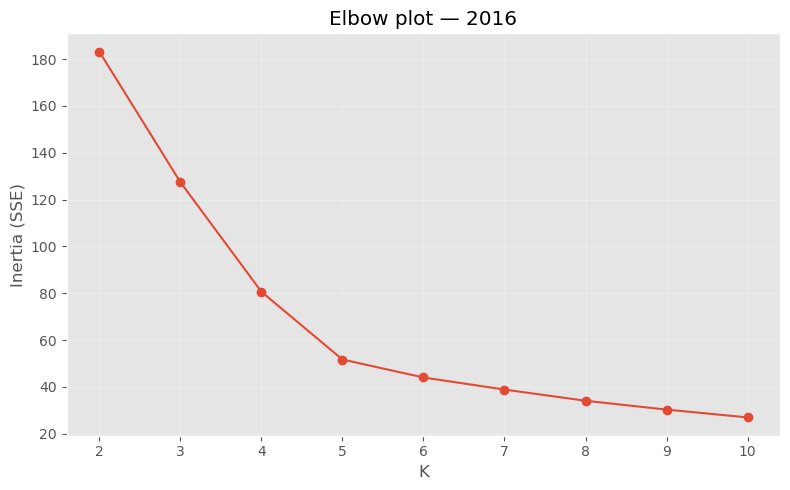

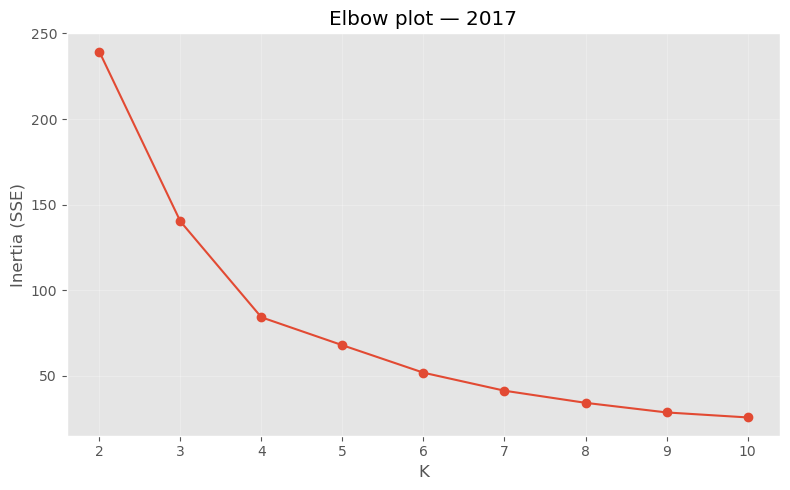

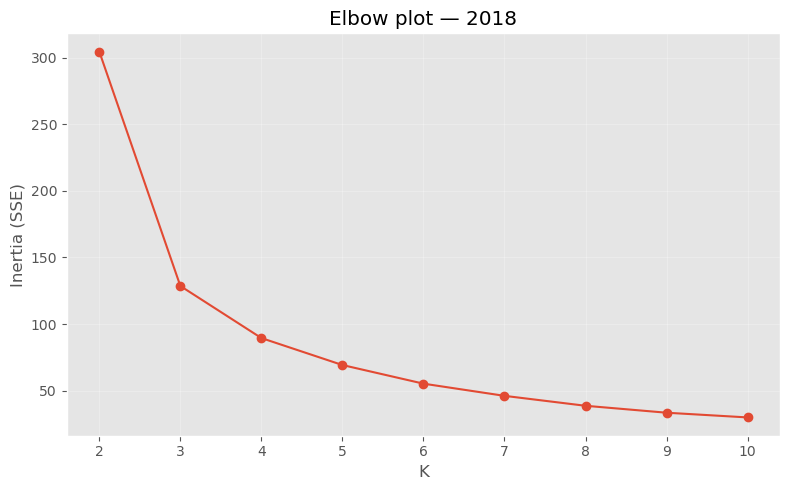

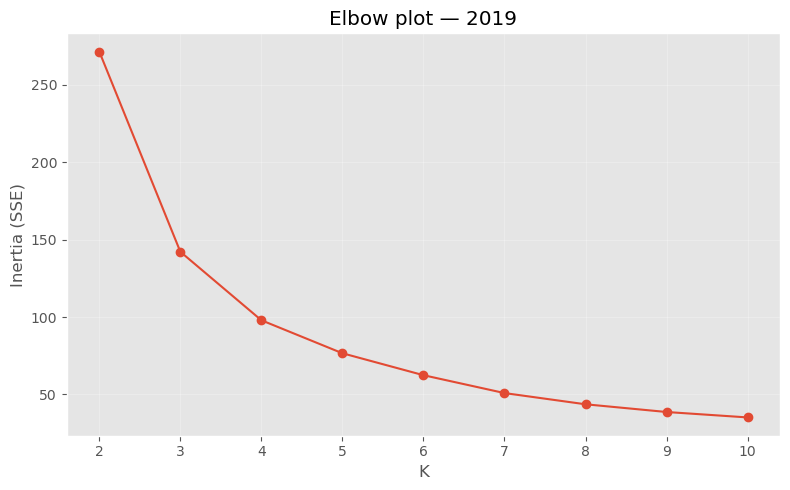

[WARN] 2020: no rows with complete betas; skip elbow.
[WARN] 2021: no rows with complete betas; skip elbow.
[WARN] 2022: no rows with complete betas; skip elbow.
[WARN] 2023: no rows with complete betas; skip elbow.


In [265]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from pathlib import Path

BETA_COLS = [
    "beta_pov_rate",
    "beta_log_density",
    "beta_share_child",
    "beta_share_teen",
    "beta_share_young",
    "beta_share_old",
]
IN_CSV = Path("./Outputs/gwr_outputs_by_year.csv")

df_gwr = pd.read_csv(IN_CSV)

def plot_elbow_for_year(df_year, year, ks=range(2, 11), save=False):
    # keep rows with complete beta vectors
    dfy = df_year.dropna(subset=BETA_COLS).copy()
    if dfy.empty:
        print(f"[WARN] {year}: no rows with complete betas; skip elbow.")
        return

    X = dfy[BETA_COLS].to_numpy()
    X = StandardScaler().fit_transform(X)

    sse = []
    for k in ks:
        km = KMeans(n_clusters=k, n_init=50, random_state=42)
        km.fit(X)
        sse.append(km.inertia_)

    plt.figure(figsize=(8,5))
    plt.plot(list(ks), sse, marker="o")
    plt.xlabel("K")
    plt.ylabel("Inertia (SSE)")
    plt.title(f"Elbow plot — {year}")
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show() 

    if save:
        out = Path(f"./Outputs/elbow_{year}.png")
        plt.savefig(out, dpi=200)
        print(f"Saved: {out}")

for yr in YEARS:
    plot_elbow_for_year(df_gwr[df_gwr["YEAR"] == yr], yr)


In [266]:
from sklearn.metrics import silhouette_score

K_FIXED = 5
rows = []

for yr in YEARS:
    dfy = df_gwr[df_gwr["YEAR"] == yr].dropna(subset=BETA_COLS).copy()
    if dfy.empty:
        print(f"[WARN] {yr}: no rows for clustering.")
        continue

    X = StandardScaler().fit_transform(dfy[BETA_COLS].to_numpy())
    km = KMeans(n_clusters=K_FIXED, n_init=100, random_state=42)
    labels = km.fit_predict(X)
    sil = silhouette_score(X, labels)

    dfy["cluster_id"] = labels
    dfy["silhouette"] = sil
    rows.append(dfy[["ZCTA","YEAR","cluster_id","silhouette"] + BETA_COLS])

    print(f"[{yr}] KMeans (K={K_FIXED}) silhouette={sil:.3f}")

clusters_fixed = pd.concat(rows, ignore_index=True)
clusters_fixed.to_csv("./Outputs/clusters_by_year_K5.csv", index=False)
print("Saved: ./Outputs/clusters_by_year_K5.csv")


[WARN] 2013: no rows for clustering.
[WARN] 2014: no rows for clustering.
[WARN] 2015: no rows for clustering.
[2016] KMeans (K=5) silhouette=0.523
[2017] KMeans (K=5) silhouette=0.512
[2018] KMeans (K=5) silhouette=0.521
[2019] KMeans (K=5) silhouette=0.465
[WARN] 2020: no rows for clustering.
[WARN] 2021: no rows for clustering.
[WARN] 2022: no rows for clustering.
[WARN] 2023: no rows for clustering.
Saved: ./Outputs/clusters_by_year_K5.csv


**According to the above results, optimal K = 5 is choosen**
**clusters_by_year_K5 is used for clustering analysis in Tableau**